# GLBL 570 · Week 7 — Fundamentals of GIS & Mapping: Companion Notebook

This notebook carries out the GIS operations of **`GLBL570_Week7_v5.pptx`** in Python, **in the order of the slides**. Each heading gives the slide number(s).
The same data are packed for QGIS in **`lab_data/`** (Shapefiles, CSV tables, GeoTIFF rasters), so every step here has a QGIS equivalent, marked **QGIS:**.

| Notebook section | v5 slides | What you do with the data |
|---|---|---|
| 0 Data pack | — | What is in `lab_data/` and how to add each file in QGIS |
| 1 What is GIS? | 4–6 | Open layers; one object = geometry + attributes; the GIS functions |
| 2 Why space matters | 7–9 | Same numbers as a ranked chart vs. a map; a point pattern (Snow) |
| 3 Geospatial data | 10–20 | Vector vs. raster, points/lines/polygons, attribute table, real rasters (satellite, DEM, land cover), VAT, **table join** (counties + countries), **lat/lon → points**, .csv/.dbf/.csvt, other formats, metadata |
| 4 Coordinate systems & projections | 21–25 | Wrong-CRS mistakes, degrees vs. metres, 1° of longitude, datums, projection families (U.S. and world) |
| 5 Cartographic design | 26–34 | Purpose, map elements, scale bars, vector symbols, generalisation, colour-blind check, **raster renderers**, colour schemes, **classification** |
| 6 Critical & ethical perspectives | 35–41 | Breaks, colour direction, projection, normalisation, moving breaks over time, omission, redlining, MAUP & gerrymandering, protecting locations |
| 7 Discussion | 42–43 | (discussion prompts) |
| 8 Lab & milestone | 44–45 (+48, 64) | **World choropleth** (GDP per capita / ND-GAIN), U.S. final map, **spatial join** of CSV points, **zonal statistics** from rasters, Moran's I, OSINT layer, memo |
| Appendix | 46–64 | GIS vs. remote sensing, cut slides, layers, Plate Carrée, polar projection, eight places, AI prompt template |

**Run** from the repository root (`Global_study_experiments/`). Environment: `geopandas`, `mapclassify`, `rasterio`, `pyproj`, `scipy`, `matplotlib` (see `requirements.txt`). CPU only, no internet needed. Outputs go to `outputs/`.

In [1]:
import json
import os
import warnings
from pathlib import Path

import pyproj
os.environ.setdefault("PROJ_DATA", pyproj.datadir.get_data_dir())   # tell GDAL where proj.db is (avoids a PROJ warning on some installs)
warnings.filterwarnings("ignore", message="Numba not installed")         # mapclassify falls back to pure Python: same results

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import mapclassify as mc
import pyogrio
import rasterio
from rasterio import features
from rasterio.plot import plotting_extent
from shapely.geometry import LineString, Polygon

LAB = Path("lab_data")                                  # QGIS-ready pack: vector/ tables/ raster/ other_formats/
VEC, TAB, RAS = LAB / "vector", LAB / "tables", LAB / "raster"
CSV = TAB / "acs2022_county_attributes.csv"
GPKG = Path("us_census_gis_lab 2") / "us_census_acs2022.gpkg"   # original GeoPackage (same counties; WGS 84 3-D quakes)
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)

SOURCE = ("Sources: U.S. Census Bureau, 2018–2022 ACS 5-Year Estimates; "
          "U.S. Geological Survey Earthquake Catalog.")
RNG = np.random.default_rng(570)          # fixed seed: jitter / permutations are reproducible
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "font.size": 9})
MISSING = {"color": "lightgrey", "hatch": "////", "edgecolor": "0.55", "linewidth": 0.1, "label": "No data"}
print("geopandas", gpd.__version__, "| mapclassify", mc.__version__, "| rasterio", rasterio.__version__, "| pyproj", pyproj.__version__)

geopandas 1.0.1 | mapclassify 2.8.1 | rasterio 1.3.8 | pyproj 3.6.1


In [2]:
# Small cartography helpers used throughout (scale bar, north arrow, source line, graticule).
def add_scale_bar(ax, length_km, x=0.04, y=0.05):
    # Valid only when the axes are in a projected CRS with metre units.
    x0, x1 = ax.get_xlim(); y0, y1 = ax.get_ylim()
    sx, sy = x0 + x * (x1 - x0), y0 + y * (y1 - y0)
    ax.plot([sx, sx + length_km * 1000], [sy, sy], color="k", lw=3, solid_capstyle="butt")
    ax.text(sx + length_km * 500, sy + 0.015 * (y1 - y0), f"{length_km:,} km", ha="center", va="bottom", fontsize=7)


def add_north_arrow(ax, x=0.95, y=0.88):
    ax.annotate("N", xy=(x, y), xytext=(x, y - 0.09), xycoords="axes fraction", ha="center",
                fontsize=10, fontweight="bold", arrowprops=dict(facecolor="k", width=3, headwidth=9))


def add_source(ax, text=SOURCE):
    ax.annotate(text, xy=(0, -0.01), xycoords="axes fraction", va="top", fontsize=6.5, color="0.35")


def graticule(crs, lons=range(-130, -59, 10), lats=range(20, 56, 5)):
    lines = [LineString([(lo, la) for la in np.linspace(min(lats), max(lats), 60)]) for lo in lons]
    lines += [LineString([(lo, la) for lo in np.linspace(min(lons), max(lons), 120)]) for la in lats]
    return gpd.GeoSeries(lines, crs=4269).to_crs(crs)


def read_raster(name, band=None):
    # Returns (masked array, matplotlib extent, open-file profile); nodata cells are masked.
    with rasterio.open(RAS / name) as src:
        arr = src.read(band, masked=True) if band else src.read(masked=True)
        return arr, plotting_extent(src), src.profile


REGION = {**dict.fromkeys("CT ME MA NH RI VT NJ NY PA".split(), "Northeast"),
          **dict.fromkeys("IL IN MI OH WI IA KS MN MO NE ND SD".split(), "Midwest"),
          **dict.fromkeys("DE DC FL GA MD NC SC VA WV AL KY MS TN AR LA OK TX".split(), "South"),
          **dict.fromkeys("AZ CO ID MT NV NM UT WY AK CA HI OR WA".split(), "West")}

---
## 0 · The data pack (`lab_data/`) — what students load into QGIS
Everything below comes from `lab_data/`. Shapefiles and GeoTIFFs open by drag-and-drop; CSV tables are added with **Layer → Add Layer → Add Delimited Text Layer** and then either **joined** (no geometry) or **geocoded** (X = longitude, Y = latitude). `lab_data/README.md` lists sources and field names.

In [3]:
HOW = {".shp": "drag & drop (vector layer)", ".tif": "drag & drop (raster layer)", ".geojson": "drag & drop (vector layer)",
       ".kml": "drag & drop (vector layer)", ".csv": "Add Delimited Text Layer"}
inv = [{"file": str(p.relative_to(LAB)), "MB": round(p.stat().st_size / 1e6, 2), "QGIS": HOW[p.suffix]}
       for p in sorted(LAB.rglob("*")) if p.suffix in HOW]
display(pd.DataFrame(inv))

,file,MB,QGIS
0,other_formats/illinois_counties.geojson,0.16,drag & drop (vector layer)
1,other_formats/illinois_counties.kml,0.27,drag & drop (vector layer)
2,raster/champaign_sentinel2_2023_10m.tif,22.65,drag & drop (raster layer)
3,raster/illinois_dem_srtm_150m.tif,5.32,drag & drop (raster layer)
4,raster/illinois_landcover_nlcd2021_150m.tif,1.73,drag & drop (raster layer)
5,raster/illinois_worldpop_2020_1km.tif,0.55,drag & drop (raster layer)
6,raster/nlcd_classes.csv,0.00,Add Delimited Text Layer
7,tables/acs2022_county_attributes.csv,0.71,Add Delimited Text Layer
8,tables/ndgain_climate_index_2022.csv,0.01,Add Delimited Text Layer
9,tables/ucdp_ged_events_2023.csv,3.68,Add Delimited Text Layer


---
## 1 · What Is GIS? (slides 4–6)
Slide 5: GIS is *"a system for capturing, storing, checking, integrating, manipulating, analyzing and displaying spatial data"* — and, as a science, the study of geographic processes and patterns.

### 1.1 Open the layers (slide 5 "storing")
**QGIS:** drag `lab_data/vector/us_counties_acs2022.shp` (and the other `.shp` files) into the map canvas.
A Shapefile's `.dbf` allows field names of **at most 10 characters**, so long ACS names were shortened; `us_counties_acs2022_field_dictionary.csv` maps them back.

In [4]:
FIELDS = pd.read_csv(VEC / "us_counties_acs2022_field_dictionary.csv")
SHORT2LONG = dict(zip(FIELDS.shapefile_field, FIELDS.acs_field))
display(FIELDS[FIELDS.acs_field != FIELDS.shapefile_field].head(8))

counties_geom = gpd.read_file(VEC / "us_counties_geometry.shp")                         # geometry + IDs only (join target)
counties = gpd.read_file(VEC / "us_counties_acs2022.shp").rename(columns=SHORT2LONG)   # same counties + ACS attributes
quakes = gpd.read_file(VEC / "usgs_earthquakes_2025_m25.shp")                           # USGS points, M >= 2.5, 2025
quakes["depth_km"] = quakes.geometry.z                                                  # 3-D points: z = depth (km)
for name, g in [("us_counties_geometry", counties_geom), ("us_counties_acs2022", counties), ("usgs_earthquakes_2025_m25", quakes)]:
    print(f"{name:28s} rows={len(g):5d}  cols={g.shape[1]:3d}  geometry={g.geom_type.unique()}  CRS={g.crs.to_string()}")

,acs_field,shapefile_field
2,county_fips,cnty_fips
5,county_name,cnty_name
6,county_label,cnty_label
9,population,pop
10,pop_density_km2,pop_dens
11,median_hh_income,med_income
12,poverty_universe,pov_univ
13,below_poverty,below_pov


us_counties_geometry         rows= 3144  cols= 10  geometry=['Polygon' 'MultiPolygon']  CRS=EPSG:4269
us_counties_acs2022          rows= 3144  cols= 33  geometry=['Polygon' 'MultiPolygon']  CRS=EPSG:4269
usgs_earthquakes_2025_m25    rows= 3754  cols= 22  geometry=['Point']  CRS=EPSG:4269


### 1.2 The GIS functions of slide 6, mapped to this notebook
| Function (slide 6) | Where it happens here |
|---|---|
| Capture | `scripts/` download Census, USGS, World Bank, ND-GAIN, UCDP, Google Earth Engine rasters |
| Store | Shapefile / GeoPackage / CSV / GeoTIFF in `lab_data/` (§3.8) |
| Check (quality) | sentinel values, join match rates, metadata (§3.6, §3.9) |
| Integrate | attribute joins (§3.6), spatial joins and zonal statistics (§8.3) |
| Manipulate | reprojection (§4), generalisation (§5.3), aggregation (§6.4) |
| Analyse | classification (§5.6), spatial statistics (§8.3–8.4) |
| Display | symbology, colour, map elements (§5), export (§8) |

### 1.3 One GIS object = one geometry + one row of attributes
This example uses Champaign County, IL (`GEOID 17019`). The polygon is the *geometry*, and the fields are its *attributes*. (Appendix A.1, slide 50, contrasts this with remote sensing, which starts from a signal.)

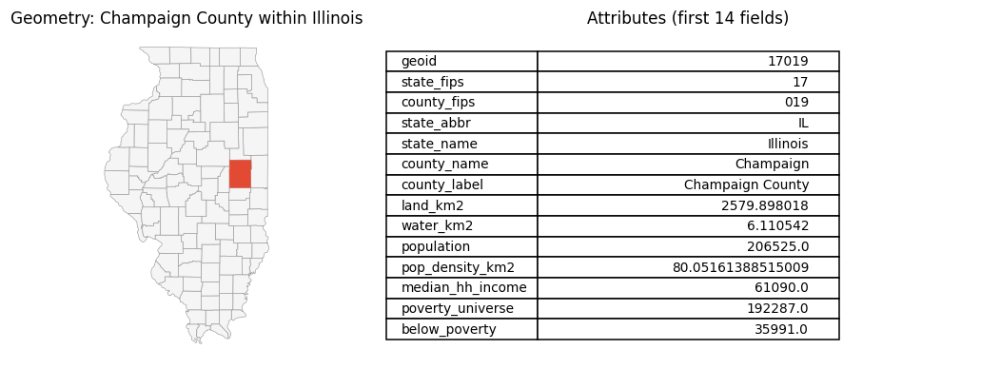

Geometry type: Polygon | vertices: 26 | WKT starts: POLYGON ((-88.463634 40.218257, -88.46072 40.223322, -88.460418 40.281935, -88.4 ...
(A Shapefile returns one-part counties as Polygon; the GeoPackage stores every county as MultiPolygon.)


In [5]:
champaign = counties[counties.geoid == "17019"]
fig, (ax_map, ax_tab) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw={"width_ratios": [1, 1.4]})
counties[counties.state_fips == "17"].plot(ax=ax_map, color="whitesmoke", edgecolor="0.6", lw=0.4)
champaign.plot(ax=ax_map, color="#e34a33")
ax_map.set_title("Geometry: Champaign County within Illinois"); ax_map.set_axis_off()

row = champaign.drop(columns="geometry").T.iloc[:14]
ax_tab.axis("off"); ax_tab.set_title("Attributes (first 14 fields)")
ax_tab.table(cellText=row.values, rowLabels=row.index, loc="center", colWidths=[0.5]).scale(1, 1.05)
plt.tight_layout(); plt.show()

geom = champaign.geometry.iloc[0]
print("Geometry type:", geom.geom_type, "| vertices:", len(gpd.GeoSeries([geom]).get_coordinates()), "| WKT starts:", geom.wkt[:80], "...")
print("(A Shapefile returns one-part counties as Polygon; the GeoPackage stores every county as MultiPolygon.)")

---
## 2 · Why Space Matters (slides 7–9)
Slide 8: *"where" is a variable* — location shapes exposure, connectivity, vulnerability and opportunity. Slide 9: *the same data, a different story* — a table ranks places, a map shows neighbours, clusters and corridors (Snow's 1854 cholera map).

### 2.1 The table/chart view: a ranking with no geography (slide 9)

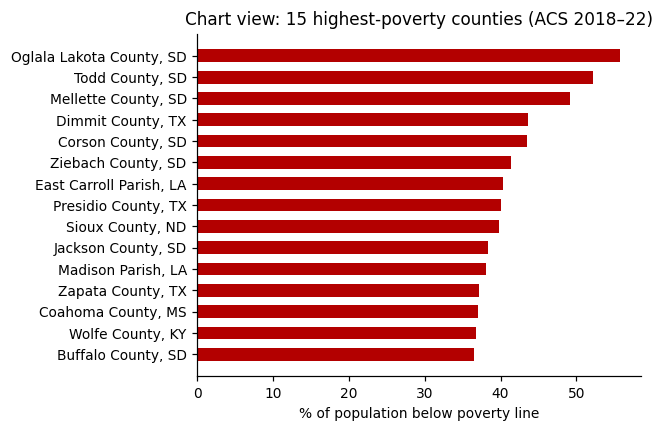

In [6]:
top = counties.nlargest(15, "poverty_pct")[["county_label", "state_abbr", "poverty_pct", "population"]]
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(top.county_label + ", " + top.state_abbr, top.poverty_pct, color="#b30000", height=0.6)
ax.invert_yaxis(); ax.set_xlabel("% of population below poverty line")
ax.set_title("Chart view: 15 highest-poverty counties (ACS 2018–22)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

### 2.2 The map view: the same numbers reveal clusters (slide 9)
The highest-poverty 5% of counties are outlined below. In the chart they were a list. On the map they form regions: the Mississippi Delta, Appalachia, the Rio Grande border, the Black Belt, and reservation counties in the Dakotas.
(The map uses the Albers equal-area projection, which §4 explains.)

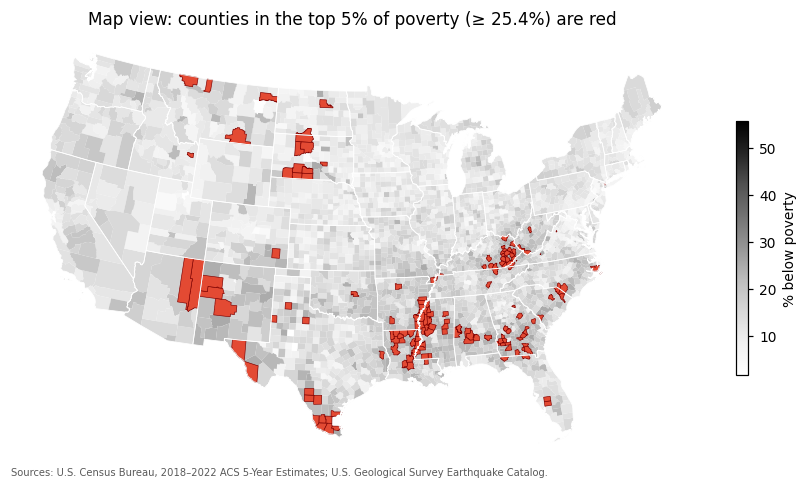

States holding the top-5% counties:
{'MS': 21, 'KY': 21, 'GA': 20, 'LA': 17, 'TX': 16, 'SD': 9, 'AR': 7, 'AL': 7, 'SC': 5, 'FL': 4}


In [7]:
lower48 = counties[~counties.state_abbr.isin(["AK", "HI"])].to_crs(5070)
states = counties.dissolve(by="state_abbr", aggfunc={"state_name": "first", "population": "sum",
                                                     "below_poverty": "sum", "poverty_universe": "sum"}).reset_index()
states48 = states[~states.state_abbr.isin(["AK", "HI"])].to_crs(5070)

thr = counties.poverty_pct.quantile(0.95)
fig, ax = plt.subplots(figsize=(10, 6))
lower48.plot(ax=ax, column="poverty_pct", cmap="Greys", lw=0, legend=True,
             legend_kwds={"shrink": 0.5, "label": "% below poverty"})
lower48[lower48.poverty_pct >= thr].plot(ax=ax, facecolor="#e34a33", edgecolor="#7f0000", lw=0.4)
states48.boundary.plot(ax=ax, color="white", lw=0.5)
ax.set_title(f"Map view: counties in the top 5% of poverty (≥ {thr:.1f}%) are red"); ax.set_axis_off()
add_source(ax); plt.show()

print("States holding the top-5% counties:")
print(counties[counties.poverty_pct >= thr].state_abbr.value_counts().head(10).to_dict())

### 2.3 Snow 1854 → today: a point pattern drives the decision (slide 9; Ebola case in Appendix, slide 52)
John Snow mapped cholera deaths as points and saw that they clustered around one water pump. The same kind of point-pattern reading works on the 2025 earthquake catalogue: the points cluster along known structures (the Pacific margin, the Alaska subduction zone) and also in places that suggest induced seismicity (Oklahoma, west Texas).

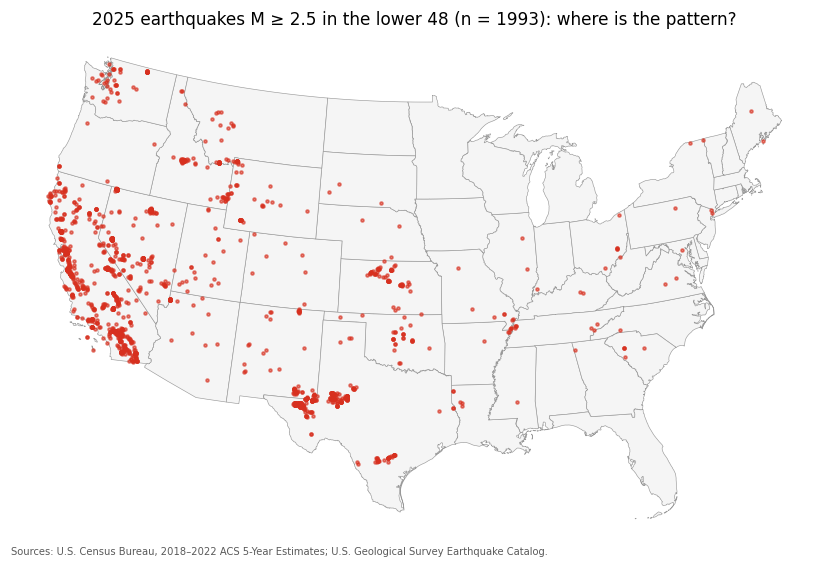

In [8]:
q48 = quakes.to_crs(5070).clip(states48.total_bounds)
fig, ax = plt.subplots(figsize=(10, 6))
states48.plot(ax=ax, color="whitesmoke", edgecolor="0.6", lw=0.4)
q48.plot(ax=ax, markersize=4, color="#d7301f", alpha=0.6)
ax.set_title(f"2025 earthquakes M ≥ 2.5 in the lower 48 (n = {len(q48)}): where is the pattern?"); ax.set_axis_off()
add_source(ax); plt.show()

---
## 3 · Geospatial Data (slides 10–20)

### 3.1 Vector or raster: which one, and why (slides 11–12)
The same piece of the world can be modelled two ways. **Vector** suits things with defined borders (counties, buildings); **raster** suits continuous surfaces (elevation, temperature, land cover).
Below, Illinois population appears as county polygons (vector) and as a 1 km WorldPop grid (raster), next to a DEM — a surface that has no natural polygons.
**QGIS:** drag `raster/illinois_worldpop_2020_1km.tif` and `raster/illinois_dem_srtm_150m.tif` onto the canvas.

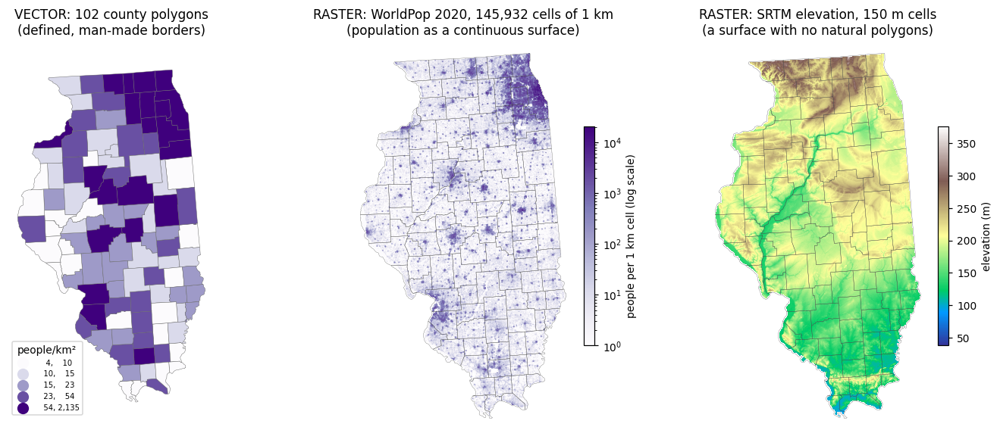

In [9]:
il = counties[counties.state_fips == "17"]
il5070 = il.to_crs(5070)
wp, wp_ext, wp_prof = read_raster("illinois_worldpop_2020_1km.tif", 1)
dem, dem_ext, dem_prof = read_raster("illinois_dem_srtm_150m.tif", 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 5.2))
il5070.plot(ax=axes[0], column="pop_density_km2", scheme="Quantiles", k=5, cmap="Purples", edgecolor="0.4", lw=0.3,
            legend=True, legend_kwds={"fmt": "{:,.0f}", "loc": "lower left", "fontsize": 6.5, "title": "people/km²"})
axes[0].set_title("VECTOR: 102 county polygons\n(defined, man-made borders)")
im = axes[1].imshow(wp, extent=wp_ext, cmap="Purples", norm=mpl.colors.LogNorm(vmin=1, vmax=float(wp.max())))
fig.colorbar(im, ax=axes[1], shrink=0.6, label="people per 1 km cell (log scale)")
axes[1].set_title(f"RASTER: WorldPop 2020, {wp.count():,} cells of 1 km\n(population as a continuous surface)")
im = axes[2].imshow(dem, extent=dem_ext, cmap="terrain")
fig.colorbar(im, ax=axes[2], shrink=0.6, label="elevation (m)")
axes[2].set_title("RASTER: SRTM elevation, 150 m cells\n(a surface with no natural polygons)")
for a in axes[1:]:
    il5070.boundary.plot(ax=a, color="0.3", lw=0.2)
for a in axes:
    a.set_axis_off()
plt.tight_layout(); plt.show()

### 3.2 Vector data: points, lines, polygons (slide 13)
Vectors are built from coordinates. The data pack contains **points** (earthquakes) and **polygons** (counties). A **line** layer can be derived by turning the state polygons into their boundary lines.

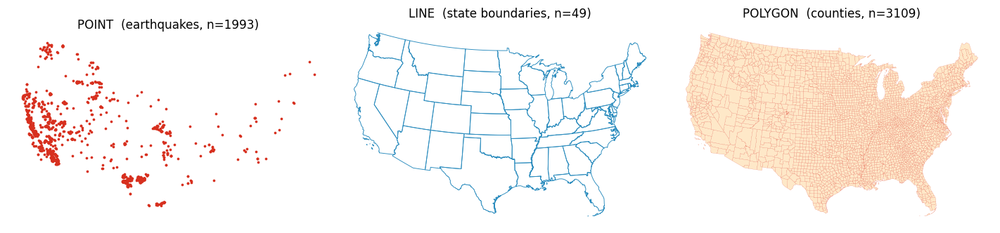

Geometry types: ['Point'] ['MultiLineString' 'LineString'] ['Polygon' 'MultiPolygon']
Earthquake points are 3-D: z = depth (km). Example: POINT Z (-119.215 38.7512 10.4)


In [10]:
state_lines = states48.boundary                       # polygon -> line
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
q48.plot(ax=axes[0], markersize=2, color="#d7301f");                     axes[0].set_title(f"POINT  (earthquakes, n={len(q48)})")
state_lines.plot(ax=axes[1], color="#2b8cbe", lw=0.6);                  axes[1].set_title(f"LINE  (state boundaries, n={len(state_lines)})")
lower48.plot(ax=axes[2], color="#fee8c8", edgecolor="#e34a33", lw=0.1); axes[2].set_title(f"POLYGON  (counties, n={len(lower48)})")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()
print("Geometry types:", quakes.geom_type.unique(), state_lines.geom_type.unique(), counties.geom_type.unique())
print("Earthquake points are 3-D: z = depth (km). Example:", quakes.geometry.iloc[0])

### 3.3 The attribute table (slide 14)
Vectors have a front-end **geometry** and a back-end database, the **attribute table**: *rows = unique geometries, columns = variables.*
**QGIS:** right-click the layer → *Open Attribute Table*. In the Shapefile the columns carry the short `.dbf` names (§1.1).

In [11]:
attr = counties.drop(columns="geometry")
print(f"{attr.shape[0]} rows (one per county)  ×  {attr.shape[1]} columns (variables)")
display(attr.head())
print(attr.dtypes.value_counts().to_dict())

3144 rows (one per county)  ×  32 columns (variables)


,geoid,state_fips,county_fips,state_abbr,state_name,county_name,county_label,land_km2,water_km2,population,...,commuters_total,commute_drive_alone,commute_carpool,commute_transit,commute_bicycle,commute_walk,commute_other,commute_wfh,transit_pct,wfh_pct
0,13233,13,233,GA,Georgia,Polk,Polk County,803.775591,4.664760,43019.0,...,17896.0,14743.0,1698.0,76.0,16.0,209.0,331.0,823.0,0.424676,4.598793
1,21023,21,023,KY,Kentucky,Bracken,Bracken County,524.900457,16.279752,8420.0,...,3557.0,2767.0,489.0,12.0,0.0,45.0,48.0,196.0,0.337363,5.510261
2,28153,28,153,MS,Mississippi,Wayne,Wayne County,2099.745602,7.255476,19760.0,...,7398.0,6193.0,572.0,0.0,0.0,132.0,228.0,273.0,0.000000,3.690187
3,42001,42,001,PA,Pennsylvania,Adams,Adams County,1343.400757,7.771555,104604.0,...,50568.0,39984.0,3897.0,113.0,198.0,1764.0,297.0,4315.0,0.223461,8.533064
4,04007,04,007,AZ,Arizona,Gila,Gila County,12322.070148,96.465330,53419.0,...,18434.0,13518.0,2658.0,7.0,37.0,391.0,195.0,1628.0,0.037973,8.831507


{dtype('float64'): 25, dtype('O'): 7}


### 3.4 Raster data (1/2): georeferenced cells with measurable values (slide 15)
Slide 15 lists aerial photographs, digital elevation models and scanned maps. The pack has three such rasters, all in EPSG:5070:
a **Sentinel-2** satellite image of Champaign–Urbana (10 m, 4 bands), the **SRTM DEM** (150 m) and **NLCD 2021 land cover** (150 m).
Unlike an ordinary picture, each pixel sits at a real location and stores a *measurement*. The cell below reads all three at the same point (the UIUC Main Quad).
**QGIS:** *Identify Features* tool (i) → click on the raster.

In [12]:
NLCD_VAT = pd.read_csv(RAS / "nlcd_classes.csv")
NLCD_LABEL = dict(zip(NLCD_VAT.value, NLCD_VAT.label))
quad_lonlat = (-88.2272, 40.1074)                                   # UIUC Main Quad
qx, qy = pyproj.Transformer.from_crs(4326, 5070, always_xy=True).transform(*quad_lonlat)

rows = []
for name in ["champaign_sentinel2_2023_10m.tif", "illinois_dem_srtm_150m.tif", "illinois_landcover_nlcd2021_150m.tif"]:
    with rasterio.open(RAS / name) as src:
        val = list(src.sample([(qx, qy)]))[0]
        rows.append({"raster": name, "CRS": src.crs.to_string(), "cell size (m)": src.res[0], "bands": src.count,
                     "dtype": src.dtypes[0], "value at Main Quad": dict(zip(src.descriptions, val.tolist()))})
display(pd.DataFrame(rows))
print("NLCD class there:", NLCD_LABEL[int(rows[2]['value at Main Quad']['nlcd_class'])])
print("Georeferencing of the DEM (affine transform: cell size, origin):\n", dem_prof["transform"])

,raster,CRS,cell size (m),bands,dtype,value at Main Quad
0,champaign_sentinel2_2023_10m.tif,EPSG:5070,10.0,4,uint16,"{'B4_red': 616, 'B3_green': 790, 'B2_blue': 47..."
1,illinois_dem_srtm_150m.tif,EPSG:5070,150.0,1,int16,{'elevation_m': 227}
2,illinois_landcover_nlcd2021_150m.tif,EPSG:5070,150.0,1,uint8,{'nlcd_class': 22}


NLCD class there: Developed, low intensity
Georeferencing of the DEM (affine transform: cell size, origin):
 | 150.00, 0.00, 378600.00|
| 0.00,-150.00, 2194950.00|
| 0.00, 0.00, 1.00|


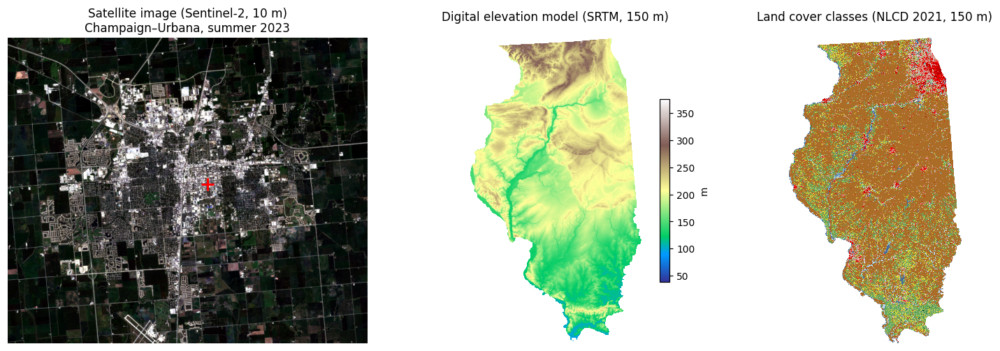

In [13]:
s2, s2_ext, _ = read_raster("champaign_sentinel2_2023_10m.tif")
nlcd, nlcd_ext, nlcd_prof = read_raster("illinois_landcover_nlcd2021_150m.tif", 1)
with rasterio.open(RAS / "illinois_landcover_nlcd2021_150m.tif") as src:
    NLCD_CMAP = {k: tuple(c / 255 for c in v) for k, v in src.colormap(1).items()}


def rgb_stretch(bands, lo=2, hi=98):
    # Percentile stretch of each band to 0-1 (what QGIS does with "Cumulative count cut 2-98%").
    out = []
    for b in bands:
        p1, p2 = np.percentile(b.compressed(), [lo, hi])
        out.append(np.clip((b.filled(p1) - p1) / (p2 - p1), 0, 1))
    return np.dstack(out)


fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
axes[0].imshow(rgb_stretch([s2[0], s2[1], s2[2]]), extent=s2_ext); axes[0].plot(qx, qy, "r+", ms=12, mew=2)
axes[0].set_title("Satellite image (Sentinel-2, 10 m)\nChampaign–Urbana, summer 2023")
im = axes[1].imshow(dem, extent=dem_ext, cmap="terrain"); fig.colorbar(im, ax=axes[1], shrink=0.6, label="m")
axes[1].set_title("Digital elevation model (SRTM, 150 m)")
lut = np.zeros((256, 4))                                            # class value -> RGBA lookup table
for k, v in NLCD_CMAP.items():
    lut[k] = v
axes[2].imshow(lut[nlcd.filled(0)], extent=nlcd_ext, interpolation="nearest")
axes[2].set_title("Land cover classes (NLCD 2021, 150 m)")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()

### 3.5 Raster data (2/2): a cell matrix, one variable per band, and the value attribute table (slide 16)
The front end of a raster is a matrix; each cell holds one number, and **one band symbolises one variable** (the Sentinel-2 file has four bands = four variables).
A categorical (integer) raster can have a **value attribute table (VAT)**: one row per *class*, not per feature.
**QGIS:** *Raster → Raster Analysis → Raster Layer Unique Values Report* produces the same table.

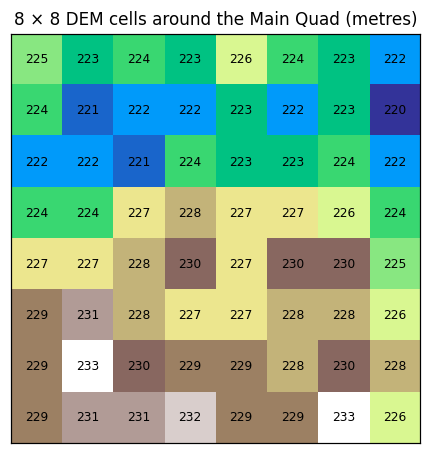

,value,label,cell_count,area_km2,share_%
0,11,Open water,105082,2364.0,1.6
1,21,"Developed, open space",143295,3224.0,2.2
2,22,"Developed, low intensity",258254,5811.0,4.0
3,23,"Developed, medium intensity",138077,3107.0,2.1
4,24,Developed high intensity,52995,1192.0,0.8
5,31,Barren land (rock/sand/clay),8658,195.0,0.1
6,41,Deciduous forest,848901,19100.0,13.1
7,42,Evergreen forest,7504,169.0,0.1
8,43,Mixed forest,64637,1454.0,1.0
9,52,Shrub/scrub,4389,99.0,0.1


In [14]:
col_f, row_f = ~dem_prof["transform"] * (qx, qy)                  # map coordinates -> fractional column/row
r_, c_ = int(row_f), int(col_f)
win = dem[r_ - 4:r_ + 4, c_ - 4:c_ + 4]
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.imshow(win, cmap="terrain")
for (i, j), v in np.ndenumerate(win):
    ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8)
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("8 × 8 DEM cells around the Main Quad (metres)")
plt.tight_layout(); plt.show()

vals, n = np.unique(nlcd.compressed(), return_counts=True)
vat = pd.DataFrame({"value": vals, "label": [NLCD_LABEL[v] for v in vals], "cell_count": n})
vat["area_km2"] = (vat.cell_count * 0.15 ** 2).round(0)
vat["share_%"] = (100 * vat.cell_count / vat.cell_count.sum()).round(1)
display(vat)

### 3.6 Tabular data (1/2): joining and geocoding (slide 17)
Slide 17 names two routes: **(1) joining** on a shared unique identifier, and **(2) geocoding** lat/lon coordinates (or addresses).

#### (1) Attribute join: `GEOID = geoid`
**QGIS:** add `tables/acs2022_county_attributes.csv` with *Add Delimited Text Layer → No geometry*, then on `us_counties_geometry` open *Layer Properties → Joins → +*, join field `geoid`, target field `GEOID`.
The README warns that the `.csvt` file must sit next to the CSV, or GEOID loses its leading zeros. The next cell reproduces that failure.

In [15]:
bad = pd.read_csv(CSV)                                  # no type hints -> geoid becomes an integer
print("Without type hints, geoid dtype =", bad.geoid.dtype, "| Autauga County, AL:", bad.geoid[bad.county_name == "Autauga"].tolist())
matched = bad.geoid.astype(str).isin(counties_geom.GEOID)
print(f"Rows that still match a GEOID: {matched.sum()} / {len(bad)}")
print("States that silently drop out of the join:", sorted(bad.loc[~matched, "state_abbr"].unique()))

Without type hints, geoid dtype = int64 | Autauga County, AL: [1001]
Rows that still match a GEOID: 2826 / 3144
States that silently drop out of the join: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT']


In [16]:
# Fix: read the key columns as text (the .csvt file does the same in QGIS).
csvt = (TAB / "acs2022_county_attributes.csvt").read_text().strip().replace('"', "").split(",")
dtypes = {c: (str if t == "String" else float) for c, t in zip(pd.read_csv(CSV, nrows=0).columns, csvt)}
attrs = pd.read_csv(CSV, dtype=dtypes)

joined = counties_geom.merge(attrs, left_on="GEOID", right_on="geoid", how="left", validate="1:1", indicator=True)
print(joined["_merge"].value_counts().to_dict())
print("Rows after join:", len(joined), "(README expects 3,144)")
check = joined.set_index("geoid")[["poverty_pct", "population"]].sort_index()
ref = counties.set_index("geoid")[["poverty_pct", "population"]].sort_index()
print("Identical to the pre-joined layer us_counties_acs2022:", np.allclose(check.values, ref.values, equal_nan=True))

{'both': 3144, 'left_only': 0, 'right_only': 0}
Rows after join: 3144 (README expects 3,144)
Identical to the pre-joined layer us_counties_acs2022: True


**The same join at world scale (country codes).** The lab slides (45, 48) ask for a *country* choropleth of GDP per capita or a climate-risk index. `world_countries_ne110m.shp` (Natural Earth) has no such numbers; they come as tables keyed by ISO 3-letter codes: `worldbank_gdp_per_capita_2022.csv` and `ndgain_climate_index_2022.csv` (ND-GAIN, Notre Dame).
Which country-code field you join on matters:

In [17]:
world = gpd.read_file(VEC / "world_countries_ne110m.shp")
gdp = pd.read_csv(TAB / "worldbank_gdp_per_capita_2022.csv", dtype={"iso3": str})
ndg = pd.read_csv(TAB / "ndgain_climate_index_2022.csv", dtype={"iso3": str})

for key in ["ISO_A3", "ISO_A3_EH"]:
    hit = world[key].isin(gdp.iso3)
    print(f"join on {key:9s}: {hit.sum()} of {len(world)} countries matched; e.g. France/Norway matched? "
          f"{world.loc[world.NAME.isin(['France', 'Norway']), key].isin(gdp.iso3).tolist()}")
print("Natural Earth codes France and Norway as ISO_A3 = '-99' (overseas territories); ISO_A3_EH holds the usable code.")

world = (world.merge(gdp[["iso3", "gdp_pc_usd"]], left_on="ISO_A3_EH", right_on="iso3", how="left").drop(columns="iso3")
              .merge(ndg[["iso3", "ndgain", "vulnerab", "readiness"]], left_on="ISO_A3_EH", right_on="iso3", how="left").drop(columns="iso3"))
missing = world.loc[world.gdp_pc_usd.isna(), "NAME"].tolist()
print(f"\nNo GDP per capita after the join ({len(missing)}):", missing)
print("World Bank rows that match no country (regional aggregates such as 'Arab World'):", (~gdp.iso3.isin(world.ISO_A3_EH)).sum())

join on ISO_A3   : 167 of 177 countries matched; e.g. France/Norway matched? [False, False]
join on ISO_A3_EH: 169 of 177 countries matched; e.g. France/Norway matched? [True, True]
Natural Earth codes France and Norway as ISO_A3 = '-99' (overseas territories); ISO_A3_EH holds the usable code.

No GDP per capita after the join (13): ['W. Sahara', 'Falkland Is.', 'Fr. S. Antarctic Lands', 'Cuba', 'North Korea', 'Taiwan', 'Eritrea', 'Yemen', 'Antarctica', 'N. Cyprus', 'Somaliland', 'Kosovo', 'S. Sudan']
World Bank rows that match no country (regional aggregates such as 'Arab World'): 91


#### (2) Geocoding from lat/lon columns
`tables/usgs_earthquakes_2025_m25_latlon.csv` is a plain table. **QGIS:** *Add Delimited Text Layer → Point coordinates*, X = `longitude`, Y = `latitude`, CRS = EPSG:4326. (Geocoding *addresses* requires a street-network service and is not shown.)

In [18]:
eq_table = pd.read_csv(TAB / "usgs_earthquakes_2025_m25_latlon.csv")
print(eq_table.head(3).to_string(index=False))
eq_pts = gpd.GeoDataFrame(eq_table, geometry=gpd.points_from_xy(eq_table.longitude, eq_table.latitude), crs="EPSG:4326")
print("Rebuilt", len(eq_pts), "points; CRS =", eq_pts.crs.to_string(),
      "| same locations as the shapefile:", np.allclose(eq_pts.geometry.x, quakes.geometry.x, atol=1e-5))

        id  longitude  latitude  depth_km  mag                                       place            time_utc
nn00891080  -119.2150   38.7512     10.40  2.6                  11 km ESE of Smith, Nevada 2025-01-01 01:51:40
us6000pmej  -169.0457   52.7864     34.83  3.2                21 km SW of Nikolski, Alaska 2025-01-01 05:04:03
us6000pgsn   -74.4804   44.9207      6.24  2.5 6 km SSE of Fort Covington Hamlet, New York 2025-01-01 05:57:00
Rebuilt 3754 points; CRS = EPSG:4326 | same locations as the shapefile: True


### 3.7 Tabular data (2/2): .csv, .dbf and .xlsx (slide 18)
- **.csv** opens everywhere; a sibling **.csvt** file tells QGIS each column's type (keeps `geoid` as text).
- **.dbf** is the attribute table inside every Shapefile; it can be opened on its own, even in Excel.
- **.xlsx**: QGIS cannot read Excel reliably — *File → Save As → CSV* in Excel first.

In [19]:
print("acs2022_county_attributes.csvt:", (TAB / "acs2022_county_attributes.csvt").read_text().strip()[:80], "...")
dbf_only = pyogrio.read_dataframe(VEC / "us_counties_acs2022.dbf", read_geometry=False)   # attribute table only
print(type(dbf_only).__name__, dbf_only.shape, "-> a plain table: the geometry lives in the .shp, not the .dbf")
display(dbf_only.iloc[:3, :8])

acs2022_county_attributes.csvt: "String","String","String","String","String","String","String","Real","Real","Re ...
DataFrame (3144, 32) -> a plain table: the geometry lives in the .shp, not the .dbf


,geoid,state_fips,cnty_fips,state_abbr,state_name,cnty_name,cnty_label,land_km2
0,13233,13,233,GA,Georgia,Polk,Polk County,803.775591
1,21023,21,023,KY,Kentucky,Bracken,Bracken County,524.900457
2,28153,28,153,MS,Mississippi,Wayne,Wayne County,2099.745602


### 3.8 Other data formats (slide 19)
GIS imports and converts KML/KMZ, GeoJSON (the web standard), GPX, NetCDF, LAS, CAD… and exports to many formats. Each format below carries a cost:
- **Shapefile** is really 4–6 sidecar files, and its `.dbf` truncates field names to 10 characters.
- **KML** is forced into WGS 84.
- **GeoJSON** is plain text and large.

In [20]:
shp_dir = OUT / "shapefile"; shp_dir.mkdir(exist_ok=True)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                    # pyogrio warns about the truncated names below
    il.to_file(shp_dir / "il_counties.shp")
il.to_file(OUT / "il_counties.geojson", driver="GeoJSON")
il.to_crs("OGC:CRS84")[["county_label", "population", "geometry"]].to_file(OUT / "il_counties.kml", driver="KML")  # KML = lon/lat WGS 84
il.to_file(OUT / "il_counties.gpkg", layer="il_counties")

files = sorted(shp_dir.iterdir()) + [OUT / "il_counties.geojson", OUT / "il_counties.kml", OUT / "il_counties.gpkg"]
display(pd.DataFrame({"file": [f.name for f in files], "size_kB": [round(f.stat().st_size / 1024, 1) for f in files]}))

dbf = gpd.read_file(shp_dir / "il_counties.dbf")       # the .dbf alone is just a table
long_names = [c for c in il.columns if len(c) > 10]
print("Field names truncated by the .dbf:", dict(zip(long_names, [c for c in dbf.columns if c not in il.columns])))

,file,size_kB
0,il_counties.cpg,0.0
1,il_counties.dbf,116.7
2,il_counties.prj,0.2
3,il_counties.shp,83.6
4,il_counties.shx,0.9
5,il_counties.geojson,229.7
6,il_counties.kml,250.2
7,il_counties.gpkg,224.0


Field names truncated by the .dbf: {'county_fips': 'county_fip', 'county_name': 'county_nam', 'county_label': 'county_lab', 'pop_density_km2': 'pop_densit', 'median_hh_income': 'median_hh_', 'poverty_universe': 'poverty_un', 'below_poverty': 'below_pove', 'poverty_pct': 'poverty_pc', 'race_two_plus': 'race_two_p', 'commuters_total': 'commuters_', 'commute_drive_alone': 'commute_dr', 'commute_carpool': 'commute_ca', 'commute_transit': 'commute_tr', 'commute_bicycle': 'commute_bi', 'commute_walk': 'commute_wa', 'commute_other': 'commute_ot', 'commute_wfh': 'commute_wf', 'transit_pct': 'transit_pc'}


In [21]:
# The pack already ships Illinois counties as GeoJSON and KML (lab_data/other_formats/): QGIS opens both by drag-and-drop.
for f in ["illinois_counties.geojson", "illinois_counties.kml"]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)                # KML timestamp fields trigger a pandas warning
        g = gpd.read_file(LAB / "other_formats" / f)
    print(f"{f:26s} {len(g)} features, CRS {g.crs.to_string()}, fields {list(g.columns)[:4]}")

illinois_counties.geojson  102 features, CRS OGC:CRS84, fields ['geoid', 'county_name', 'population', 'poverty_pct']
illinois_counties.kml      102 features, CRS EPSG:4326, fields ['Name', 'description', 'timestamp', 'begin']


### 3.9 Metadata (slide 20)
Metadata describe **content, structure, quality, lineage, and usage constraints**. Some of it can be read from the file (vector and raster). Quality has to be checked, and here the check finds a real problem in the raw CSV.

In [22]:
info = pyogrio.read_info(VEC / "us_counties_acs2022.shp")
print("Shapefile:", {k: info[k] for k in ["crs", "geometry_type", "features"]}, "| bounds:", np.round(info["total_bounds"], 2))
with rasterio.open(RAS / "illinois_dem_srtm_150m.tif") as src:
    print("GeoTIFF:  ", {"crs": src.crs.to_string(), "size": (src.width, src.height), "res": src.res, "nodata": src.nodata,
                         "dtype": src.dtypes[0], "band": src.descriptions})

# Quality check on the RAW table: summary statistics reveal a Census sentinel value in median_hh_income.
display(attrs[["population", "median_hh_income", "poverty_pct", "pop_density_km2"]].describe().T[["min", "50%", "max"]])
bad_inc = attrs[attrs.median_hh_income < 0]
print("Negative median income (ACS 'not available' code):", bad_inc[["county_label", "state_abbr", "median_hh_income"]].values.tolist())
print("In the Shapefile this value is already stored as NULL:", counties.loc[counties.geoid.isin(bad_inc.geoid), "median_hh_income"].tolist())

Shapefile: {'crs': 'EPSG:4269', 'geometry_type': 'Polygon', 'features': 3144} | bounds: [-179.15   18.92  179.78   71.35]
GeoTIFF:   {'crs': 'EPSG:5070', 'size': (2351, 4173), 'res': (150.0, 150.0), 'nodata': -32768.0, 'dtype': 'int16', 'band': ('elevation_m',)}


,min,50%,max
population,5.000000e+01,25784.500000,9.936690e+06
median_hh_income,-6.666667e+08,60931.000000,1.704630e+05
poverty_pct,1.603499e+00,13.398556,5.577648e+01
pop_density_km2,1.420278e-02,17.271909,2.804632e+04


Negative median income (ACS 'not available' code): [['Loving County', 'TX', -666666666.0]]
In the Shapefile this value is already stored as NULL: [nan]


In [23]:
# Set the sentinel to missing. If it stayed, this county would be drawn as the poorest place in America.
for g in (attrs, counties, lower48):
    g.loc[g.median_hh_income < 0, "median_hh_income"] = np.nan

# Structure checks promised by the README: category counts must sum to their totals.
race = [c for c in counties.columns if c.startswith("race_")]
commute = [c for c in counties.columns if c.startswith("commute_")]
print("race_* sums to population for all counties:   ", np.allclose(counties[race].sum(axis=1), counties.population))
print("commute_* sums to commuters_total for all:      ", np.allclose(counties[commute].sum(axis=1), counties.commuters_total))

metadata = {
    "title": "U.S. counties with ACS 2018–2022 attributes and 2025 USGS earthquakes (GLBL 570 teaching pack)",
    "content": "3,144 counties/county equivalents (50 states + DC); 3,754 earthquakes M>=2.5 in 2025",
    "structure": {"crs_counties": str(counties.crs), "crs_quakes": str(quakes.crs), "fields": list(attr.columns)},
    "quality": ["ACS values are survey estimates; margins of error not included in this pack",
                "1 county had median_hh_income = -666666666 (not available) -> set to NaN",
                "Boundaries are 1:5,000,000 cartographic; areas come from detailed TIGER, not the simplified geometry"],
    "lineage": ["Census TIGER/Line 2022 + ACS 5-year (B02001, B19013, B17001, B08301)",
                "Rasters: Google Earth Engine (SRTM, NLCD 2021, Sentinel-2 L2A, WorldPop 2020), scripts/fetch_rasters_gee.py",
                "USGS FDSN catalog 2025-01-01..2026-01-01, M>=2.5, clipped to county boundaries"],
    "constraints": "Teaching use; not for cadastral/engineering area work; earthquakes are one year only",
}
(OUT / "metadata_record.json").write_text(json.dumps(metadata, indent=2))
print("Wrote", OUT / "metadata_record.json")

race_* sums to population for all counties:    True
commute_* sums to commuters_total for all:       True
Wrote outputs/metadata_record.json


---
## 4 · Coordinate Systems & Projections (slides 21–25)

### 4.1 Why does the same data appear in different locations? (slide 22)
A coordinate system says *where* the numbers are; a projection says *how the Earth is flattened*. If a layer's CRS is **declared wrong** (a missing or wrong `.prj`), its features land in the wrong place — the classic case is metres read as degrees.
**QGIS:** a layer's CRS is in *Layer Properties → Source*; *Set Layer CRS* only relabels, *Export → Save Features As…* with a new CRS actually reprojects.

Illinois x-coordinates in metres: [378605. 731220.] -> read as longitude this is impossible (|lon| ≤ 180)


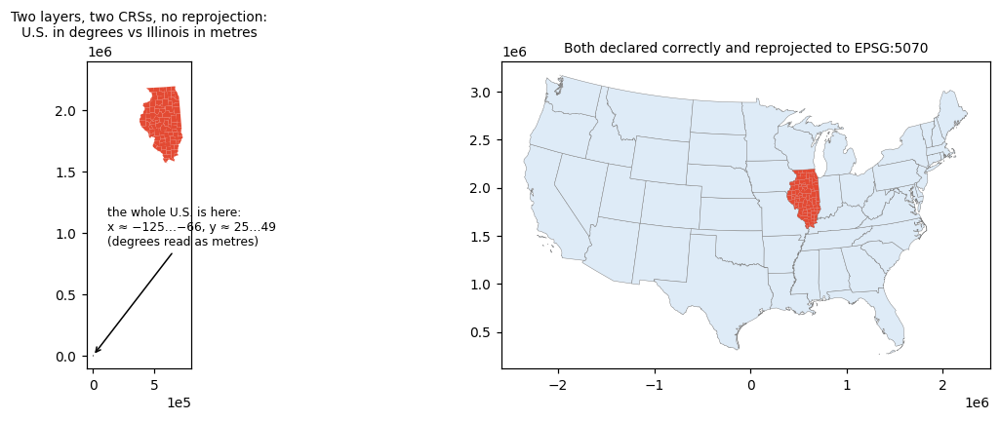

In [24]:
il_m = il.to_crs(5070)                                              # true coordinates in metres
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    wrong = il_m.set_crs(4326, allow_override=True)                 # metres mislabelled as degrees (wrong .prj)
print("Illinois x-coordinates in metres:", np.round(il_m.total_bounds[[0, 2]]), "-> read as longitude this is impossible (|lon| ≤ 180)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
states48.to_crs(4326).plot(ax=axes[0], color="#deebf7", edgecolor="0.5", lw=0.3)
il_m.plot(ax=axes[0], color="#e34a33")                              # drawn without reprojection
axes[0].annotate("the whole U.S. is here:\nx ≈ −125…−66, y ≈ 25…49\n(degrees read as metres)", xy=(-100, 40), xytext=(1.2e5, 0.9e6),
                 arrowprops=dict(arrowstyle="->", color="k"), fontsize=8)
axes[0].set_xlim(-0.5e5, 8e5); axes[0].set_ylim(-1e5, 2.4e6)
axes[0].set_title("Two layers, two CRSs, no reprojection:\nU.S. in degrees vs Illinois in metres", fontsize=9)
states48.plot(ax=axes[1], color="#deebf7", edgecolor="0.5", lw=0.3)
il_m.plot(ax=axes[1], color="#e34a33")
axes[1].set_title("Both declared correctly and reprojected to EPSG:5070", fontsize=9)
for a in axes: a.ticklabel_format(style="sci", scilimits=(0, 0))
plt.tight_layout(); plt.show()

### 4.2 Geographic vs projected coordinate systems (slide 23)
A **geographic CRS** uses angular units (degrees) on a spheroid, so lengths and areas change with latitude. A **projected CRS** uses linear units (metres) on a plane.
The test below measures area in the wrong system and in the right one.

EPSG:4269 axis units: degree | EPSG:5070 axis units: metre


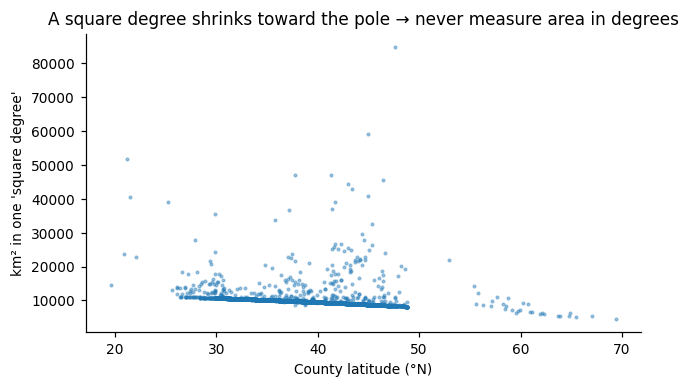

,county_label,state_abbr,area_sq_degrees,area_km2_albers,official_km2
384,Yukon-Koyukuk Census Area,AK,74.26,383026.79,382983.69
73,North Slope Borough,AK,53.18,233919.38,245603.18


In [25]:
print("EPSG:4269 axis units:", counties.crs.axis_info[0].unit_name, "| EPSG:5070 axis units:", pyproj.CRS(5070).axis_info[0].unit_name)

cmp = counties[["county_label", "state_abbr", "land_km2", "water_km2"]].copy()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")                    # geopandas warns: area in a geographic CRS is meaningless
    cmp["area_sq_degrees"] = counties.geometry.area
cmp["area_km2_albers"] = counties.to_crs(5070).area / 1e6
cmp["official_km2"] = cmp.land_km2 + cmp.water_km2
cmp["lat"] = counties.to_crs(5070).centroid.to_crs(4269).y
cmp["km2_per_sq_degree"] = cmp.official_km2 / cmp.area_sq_degrees

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.scatter(cmp.lat, cmp.km2_per_sq_degree, s=3, alpha=0.4)
ax.set_xlabel("County latitude (°N)"); ax.set_ylabel("km² in one 'square degree'")
ax.set_title("A square degree shrinks toward the pole → never measure area in degrees")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()
display(cmp.loc[cmp.state_abbr.isin(["TX", "AK"])].nlargest(2, "official_km2")[
    ["county_label", "state_abbr", "area_sq_degrees", "area_km2_albers", "official_km2"]].round(2))

Slide 23's rule of thumb: **1° of longitude ≈ 111.32 km × cos(latitude)**. At the equator that is 111 km; near the pole it shrinks toward zero (*"What about the polar area?"*).

In [26]:
geod = pyproj.Geod(ellps="GRS80")
lat = np.array([0, 15, 30, 40, 45, 60, 70, 80, 89])
display(pd.DataFrame({"latitude (°)": lat, "111.32·cos(lat) km": np.round(111.32 * np.cos(np.radians(lat)), 1),
                      "true length on GRS80 ellipsoid (km)": np.round([geod.inv(0, a, 1, a)[2] / 1000 for a in lat], 1)}).set_index("latitude (°)"))

,111.32·cos(lat) km,true length on GRS80 ellipsoid (km)
latitude (°),,
0,111.3,111.3
15,107.5,107.6
30,96.4,96.5
40,85.3,85.4
45,78.7,78.8
60,55.7,55.8
70,38.1,38.2
80,19.3,19.4
89,1.9,1.9


### 4.3 Datums: NAD83 vs WGS 84 (slide 24)
Each geographic CRS chooses an ellipsoid and an anchor (the datum). The counties use **NAD83 (EPSG:4269)**; USGS publishes earthquakes in **WGS 84 3-D (EPSG:4979)** (kept in the original GeoPackage; the pack's Shapefile was already converted to NAD83). QGIS reprojects on the fly; in code it must be done explicitly.

In [27]:
print("Counties:", counties.crs.name, "| datum:", counties.crs.datum.name)
quakes_src = gpd.read_file(GPKG, layer="usgs_earthquakes_2025_m25")   # as published by USGS
print("Quakes (USGS original):", quakes_src.crs.name, "| datum:", quakes_src.crs.datum.name)
print("Quakes (lab_data shapefile):", quakes.crs.name, "-> already converted for joining with the counties")
for src in (4267, 4979):                                         # NAD27 and WGS 84 (3-D) -> NAD83
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")                          # pyproj warns that the grid files are not installed
        group = pyproj.transformer.TransformerGroup(src, 4269)
    print(f"EPSG:{src} -> NAD83: {len(group.transformers)} usable operation(s); best = {group.transformers[0].description!r}; "
          f"grid files missing for {len(group.unavailable_operations)} more accurate one(s)")
print("Note: NAD27 -> NAD83 shifts of tens of metres need NADCON grids; without them PROJ falls back to a ballpark shift.")
print("WGS 84 -> NAD83 differ by ~1-2 m today; PROJ's default treats them as equal, which is fine at county scale.")

Counties: NAD83 | datum: North American Datum 1983
Quakes (USGS original): WGS 84 | datum: World Geodetic System 1984 ensemble
Quakes (lab_data shapefile): NAD83 -> already converted for joining with the counties
EPSG:4267 -> NAD83: 1 usable operation(s); best = 'Ballpark geographic offset from NAD27 to NAD83'; grid files missing for 9 more accurate one(s)
EPSG:4979 -> NAD83: 4 usable operation(s); best = 'Inverse of NAD83 to WGS 84 (1)'; grid files missing for 49 more accurate one(s)
Note: NAD27 -> NAD83 shifts of tens of metres need NADCON grids; without them PROJ falls back to a ballpark shift.
WGS 84 -> NAD83 differ by ~1-2 m today; PROJ's default treats them as equal, which is fine at county scale.


### 4.4 Projection families, distortion, and choosing a CRS (slide 25)
Every projection distorts something. Slide 25's table pairs surfaces (azimuthal / conic / cylindrical) with properties (equal-area / conformal / equidistant).
The cells below draw **identical 400 km geodesic circles** (Tissot-style indicatrices) and project them through five CRSs, then measure how much each circle's area changes.

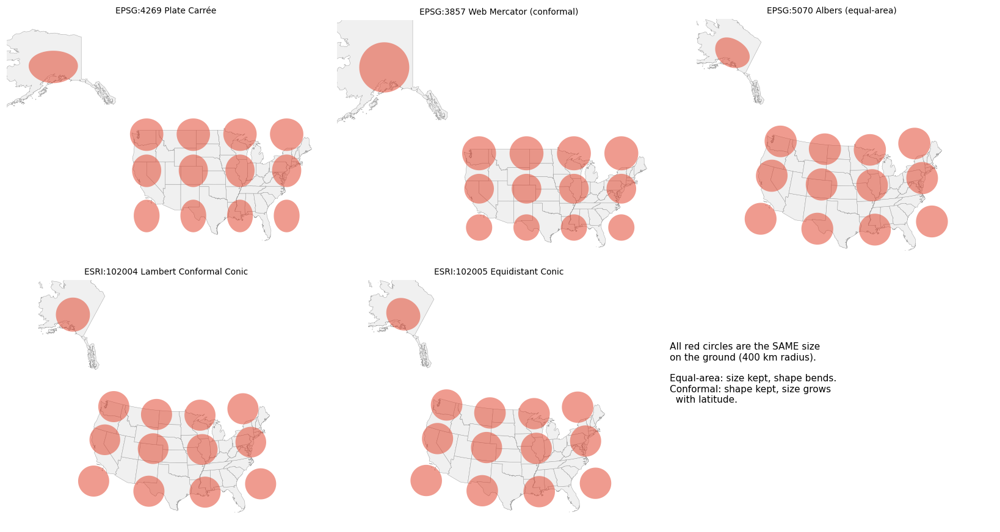

,area × at 30°N,at 48°N,at 63°N (AK)
projection,,,
EPSG:3857 Web Mercator (conformal),1.34,2.24,4.87
EPSG:5070 Albers (equal-area),1.00,1.00,1.00
ESRI:102004 Lambert Conformal Conic,1.01,1.02,1.22
ESRI:102005 Equidistant Conic,1.01,1.01,1.12


In [28]:
def geodesic_circle(lon, lat, r_km=400, n=90):
    az = np.linspace(0, 360, n, endpoint=False)
    lons, lats, _ = geod.fwd(np.full(n, lon), np.full(n, lat), az, np.full(n, r_km * 1000.0))
    return Polygon(zip(lons, lats))


centers = [(lo, la) for la in (30, 40, 48) for lo in (-120, -105, -90, -75)] + [(-150, 63)]
circles = gpd.GeoDataFrame({"lat": [c[1] for c in centers]}, geometry=[geodesic_circle(*c) for c in centers], crs=4269)
true_area = np.array([abs(geod.geometry_area_perimeter(g)[0]) for g in circles.geometry]) / 1e6

PROJS = {"EPSG:4269 Plate Carrée": 4269, "EPSG:3857 Web Mercator (conformal)": 3857,
         "EPSG:5070 Albers (equal-area)": 5070, "ESRI:102004 Lambert Conformal Conic": "ESRI:102004",
         "ESRI:102005 Equidistant Conic": "ESRI:102005"}
no_hi = states[states.state_abbr != "HI"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8)); axes = axes.ravel()
rows = []
for ax, (name, crs) in zip(axes, PROJS.items()):
    st, ci = no_hi.to_crs(crs), circles.to_crs(crs)
    st.plot(ax=ax, color="#f0f0f0", edgecolor="0.6", lw=0.3)
    ci.plot(ax=ax, color="#e34a33", alpha=0.55)
    xmin, ymin, xmax, ymax = ci.total_bounds; pad = 0.08 * (xmax - xmin)
    ax.set_xlim(xmin - pad, xmax + pad); ax.set_ylim(ymin - pad, ymax + pad)
    ax.set_title(name, fontsize=9); ax.set_axis_off()
    if crs != 4269:
        ratio = (ci.area / 1e6) / true_area
        rows.append({"projection": name, "area ×  at 30°N": ratio[circles.lat == 30].mean(),
                     "at 48°N": ratio[circles.lat == 48].mean(), "at 63°N (AK)": ratio[circles.lat == 63].mean()})
axes[-1].axis("off")
axes[-1].text(0, 0.5, "All red circles are the SAME size\non the ground (400 km radius).\n\n"
              "Equal-area: size kept, shape bends.\nConformal: shape kept, size grows\n  with latitude.", fontsize=10)
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows).set_index("projection").round(2))

**Size of the distortion in numbers.** The table above gives the area inflation of each circle; a ratio of 1.00 means area is kept. The next cell computes how large Alaska looks relative to Texas in each projection.

In [29]:
true = states.to_crs(6933).set_index("state_abbr").area                   # EPSG:6933 = global equal-area reference
out = {"true (equal-area)": true["AK"] / true["TX"]}
for name, crs in PROJS.items():
    if crs != 4269:
        a = states.to_crs(crs).set_index("state_abbr").area
        out[name] = a["AK"] / a["TX"]
display(pd.Series(out, name="Alaska area ÷ Texas area").round(2).to_frame())

,Alaska area ÷ Texas area
true (equal-area),2.22
EPSG:3857 Web Mercator (conformal),8.66
EPSG:5070 Albers (equal-area),2.22
ESRI:102004 Lambert Conformal Conic,2.76
ESRI:102005 Equidistant Conic,2.53


**The world view.** Slide 25 also asks which property to keep at *global* extent. The next cell projects the Natural Earth countries four ways and compares Greenland with Africa (Africa is about 14 times larger on the ground).

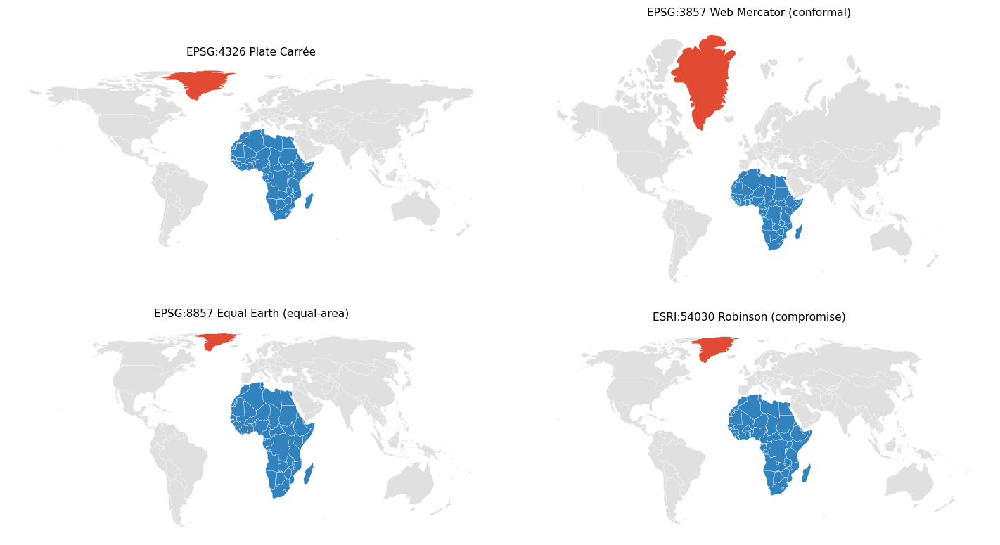

,Africa ÷ Greenland (map area)
projection,
EPSG:4326 Plate Carrée,3.8
EPSG:3857 Web Mercator (conformal),0.9
EPSG:8857 Equal Earth (equal-area),13.6
ESRI:54030 Robinson (compromise),7.2
true (on the ground),13.6


In [30]:
w_noant = world[world.CONTINENT != "Antarctica"]
true_area = w_noant.to_crs(6933).area                                # equal-area reference
ratio_true = true_area[w_noant.CONTINENT == "Africa"].sum() / true_area[w_noant.NAME == "Greenland"].sum()
WORLD_PROJ = {"EPSG:4326 Plate Carrée": 4326, "EPSG:3857 Web Mercator (conformal)": 3857,
              "EPSG:8857 Equal Earth (equal-area)": 8857, "ESRI:54030 Robinson (compromise)": "ESRI:54030"}
fig, axes = plt.subplots(2, 2, figsize=(13, 7.5)); axes = axes.ravel()
rows = []
for ax, (name, crs) in zip(axes, WORLD_PROJ.items()):
    g = w_noant.clip((-180, -80, 180, 84)).to_crs(crs)
    g.plot(ax=ax, color=np.where(g.NAME == "Greenland", "#e34a33", np.where(g.CONTINENT == "Africa", "#3182bd", "#e0e0e0")),
           edgecolor="white", lw=0.2)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        a = g.area
    rows.append({"projection": name, "Africa ÷ Greenland (map area)": round(a[g.CONTINENT == "Africa"].sum() / a[g.NAME == "Greenland"].sum(), 1)})
    ax.set_title(name, fontsize=10); ax.set_axis_off()
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows + [{"projection": "true (on the ground)", "Africa ÷ Greenland (map area)": round(ratio_true, 1)}]).set_index("projection"))

**Choosing a CRS by task and by extent (slide 25; README 25–35′)**

| Task on slide 25 | Property to keep | Example CRS |
|---|---|---|
| Population density, forest cover | **Equal-area** | EPSG:5070 (U.S.), EPSG:8857 Equal Earth (global) |
| Navigation, web maps, weather | **Conformal** | EPSG:3857 (web), Lambert Conformal Conic |
| Response time, air transport, disease spread | **Equidistant** (from a point/along lines) | ESRI:102005, Azimuthal Equidistant |

| Extent | Typical choice |
|---|---|
| Illinois / small country | State Plane (EPSG:3435 IL East) or UTM 16N (EPSG:26916) |
| Whole U.S. | EPSG:5070 Conus Albers. Filter to the lower 48 first; draw AK and HI as insets |
| Global | Equal Earth, Robinson, Winkel Tripel; check https://projectionwizard.org/ |

The next cell measures the Chicago → Los Angeles distance in each CRS and compares it with the true geodesic distance.

In [31]:
chi, la = (-87.63, 41.88), (-118.24, 34.05)
true_km = geod.inv(*chi, *la)[2] / 1000
rows = []
for name, crs in list(PROJS.items())[1:] + [("EPSG:26916 UTM 16N (local!)", 26916)]:
    p = gpd.GeoSeries(gpd.points_from_xy([chi[0], la[0]], [chi[1], la[1]]), crs=4269).to_crs(crs)
    d = p.iloc[0].distance(p.iloc[1]) / 1000
    rows.append({"CRS": name, "planar distance (km)": round(d), "error vs geodesic": f"{100 * (d / true_km - 1):+.1f}%"})
print(f"True geodesic distance: {true_km:,.0f} km")
display(pd.DataFrame(rows).set_index("CRS"))
print("A local CRS like UTM 16N (built for Illinois) is wrong for national distances, and so is Web Mercator.")

True geodesic distance: 2,809 km


,planar distance (km),error vs geodesic
CRS,,
EPSG:3857 Web Mercator (conformal),3583,+27.5%
EPSG:5070 Albers (equal-area),2790,-0.7%
ESRI:102004 Lambert Conformal Conic,2796,-0.5%
ESRI:102005 Equidistant Conic,2798,-0.4%
EPSG:26916 UTM 16N (local!),2908,+3.5%


A local CRS like UTM 16N (built for Illinois) is wrong for national distances, and so is Web Mercator.


---
## 5 · Cartographic Design (slides 26–34)

### 5.1 Same area, different activities · three key questions (slides 27–28)
Before mapping, answer: **Who wants the map? Where will it be seen? What is its purpose?**
Slide 27's point is that the same area gives different maps for different purposes. Below, Illinois is mapped three times for three questions.

{
  "who": "GLBL 570 students + Illinois policy audience",
  "where": "Letter-size handout / slide (static, small)",
  "purpose": "Compare how Illinois counties differ in poverty, transit use, and remote work"
}


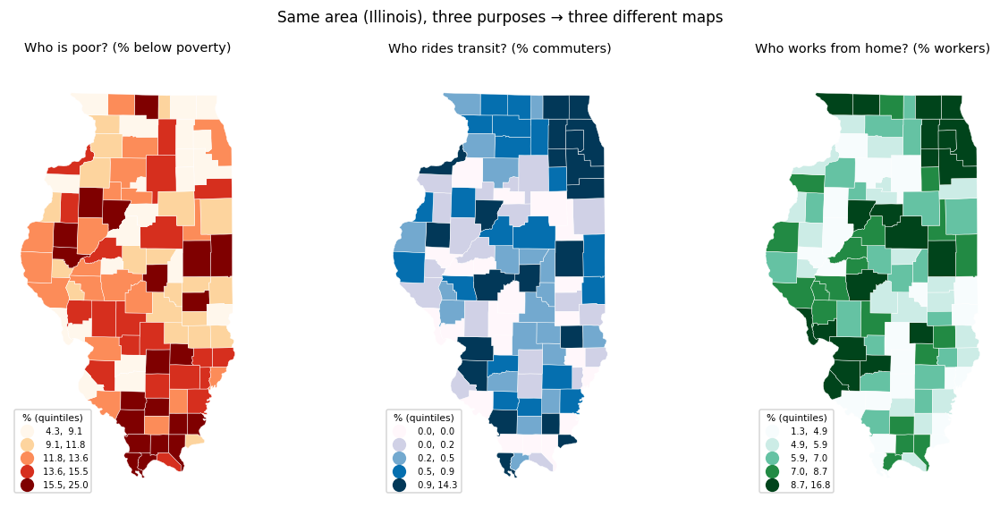

In [32]:
MAP_BRIEF = {"who": "GLBL 570 students + Illinois policy audience",
             "where": "Letter-size handout / slide (static, small)",
             "purpose": "Compare how Illinois counties differ in poverty, transit use, and remote work"}
print(json.dumps(MAP_BRIEF, indent=2))

il_sp = il.to_crs(3435)                                 # NAD83 / Illinois East (ftUS): a local CRS for one state
fig, axes = plt.subplots(1, 3, figsize=(12, 5.2))
for ax, (col, cmap, ttl) in zip(axes, [("poverty_pct", "OrRd", "Who is poor? (% below poverty)"),
                                       ("transit_pct", "PuBu", "Who rides transit? (% commuters)"),
                                       ("wfh_pct", "BuGn", "Who works from home? (% workers)")]):
    il_sp.plot(ax=ax, column=col, scheme="Quantiles", k=5, cmap=cmap, edgecolor="white", lw=0.3, legend=True,
              legend_kwds={"fmt": "{:.1f}", "loc": "lower left", "fontsize": 6.5, "title": "% (quintiles)", "title_fontsize": 7})
    ax.set_title(ttl, fontsize=9.5); ax.set_axis_off()
fig.suptitle("Same area (Illinois), three purposes → three different maps", fontsize=11)
plt.tight_layout(); plt.show()

### 5.2 Map design process & map elements (slides 29–30)
Slide 29's process: (1) assemble the data → (2) choose the data, analysis, and symbolisation → (3) add the title, legend, north arrow, scale bar, and labels.
Slide 30's building blocks: **title, legend, scale bar, graticule, north arrow, source / credits**. The function below adds them to a national map, with Alaska and Hawaii as insets in their own equal-area CRSs.

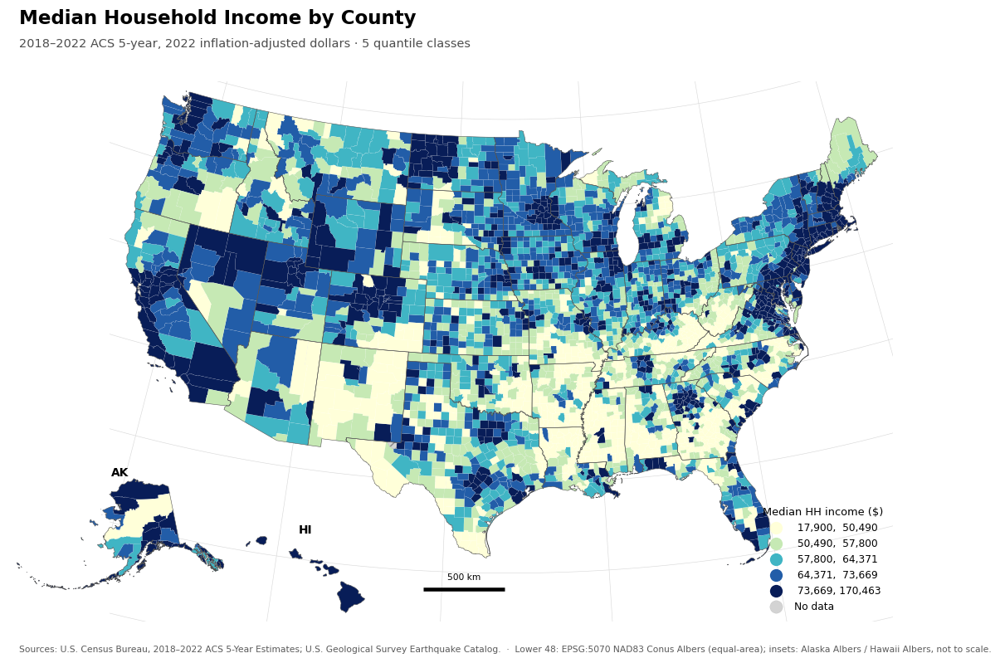

In [33]:
AK_CRS, HI_CRS = 3338, "ESRI:102007"                    # Alaska Albers, Hawaii Albers


def us_choropleth(gdf, column, bins, cmap, title, subtitle, legend_title, fmt="{:.1f}", fname=None):
    # One set of class breaks (bins) is applied to the lower 48 and both insets, so colours mean the same everywhere.
    fig = plt.figure(figsize=(11, 7.4))
    ax = fig.add_axes([0.0, 0.07, 1.0, 0.80])
    kw = dict(column=column, scheme="UserDefined", classification_kwds={"bins": list(bins)}, cmap=cmap,
              edgecolor="white", lw=0.05, missing_kwds=MISSING)
    main = gdf[~gdf.state_abbr.isin(["AK", "HI"])].to_crs(5070)
    graticule(5070).plot(ax=ax, color="0.85", lw=0.4, zorder=0)
    main.plot(ax=ax, legend=True, zorder=1, legend_kwds={"fmt": fmt, "loc": "lower right", "title": legend_title,
                                                          "fontsize": 8, "title_fontsize": 8.5, "frameon": False}, **kw)
    main.dissolve("state_abbr").boundary.plot(ax=ax, color="0.3", lw=0.35, zorder=2)
    x0, y0, x1, y1 = main.total_bounds
    ax.set_xlim(x0 - 0.02 * (x1 - x0), x1 + 0.02 * (x1 - x0)); ax.set_ylim(y0 - 0.12 * (y1 - y0), y1 + 0.02 * (y1 - y0))
    ax.set_axis_off()
    for box, st, crs in [([0.01, 0.07, 0.22, 0.26], "AK", AK_CRS), ([0.24, 0.07, 0.13, 0.14], "HI", HI_CRS)]:
        ia = fig.add_axes(box); part = gdf[gdf.state_abbr == st].to_crs(crs)
        part.plot(ax=ia, **kw); part.dissolve().boundary.plot(ax=ia, color="0.3", lw=0.35)
        if st == "AK":
            ia.set_xlim(-2.3e6, 1.6e6)                  # crop the far Aleutians
        ia.set_axis_off()
        xa, xb = ia.get_xlim()                             # label centred above the visible part of the state
        vis = part.geometry.explode(index_parts=False)
        vis = vis[(vis.centroid.x > xa) & (vis.centroid.x < xb)]
        vx0, _, vx1, vy1 = vis.total_bounds
        ia.text((vx0 + vx1) / 2, vy1, st, fontsize=9, fontweight="bold", ha="center", va="bottom")
    add_scale_bar(ax, 500, x=0.40, y=0.06)
    fig.text(0.02, 0.955, title, fontsize=15, fontweight="bold")
    fig.text(0.02, 0.92, subtitle, fontsize=9.5, color="0.3")
    fig.text(0.02, 0.025, SOURCE + "  ·  Lower 48: EPSG:5070 NAD83 Conus Albers (equal-area); insets: Alaska Albers / Hawaii Albers, not to scale.",
             fontsize=7, color="0.35")
    if fname:
        fig.savefig(OUT / f"{fname}.png", dpi=250, bbox_inches="tight"); fig.savefig(OUT / f"{fname}.pdf", bbox_inches="tight")
    return fig


inc_bins = mc.Quantiles(counties.median_hh_income.dropna(), k=5).bins
us_choropleth(counties, "median_hh_income", inc_bins, "YlGnBu", "Median Household Income by County",
              "2018–2022 ACS 5-year, 2022 inflation-adjusted dollars · 5 quantile classes", "Median HH income ($)",
              fmt="{:,.0f}", fname="map_elements_median_income")
plt.show()

**Slide 30: "Why is there no scale bar?"** On a small-scale (national or world) map the scale is *not constant*, so one bar would mislead. Web Mercator (EPSG:3857) shows this most clearly. Its local scale factor depends on latitude:

In [34]:
merc = pyproj.Proj("EPSG:3857")
lats = [25, 35, 45, 49, 61, 71]
f = merc.get_factors([-100] * len(lats), lats)
display(pd.DataFrame({"latitude": lats, "linear scale factor": np.round(f.meridional_scale, 2),
                      "area scale factor": np.round(f.areal_scale, 2)}).set_index("latitude"))
print("A 500 km bar drawn for 25°N would be ~2.5× too short for northern Alaska (71°N) on the same Mercator map.")

,linear scale factor,area scale factor
latitude,,
25,1.10,1.22
35,1.22,1.49
45,1.41,2.00
49,1.52,2.32
61,2.06,4.25
71,3.07,9.43


A 500 km bar drawn for 25°N would be ~2.5× too short for northern Alaska (71°N) on the same Mercator map.


Slide 30's answer: *scale bars belong on regional and local maps.* At state scale the distortion of a local CRS is tiny, so a scale bar and north arrow are honest:

UTM 16N scale factor across Illinois: [1.0014 0.9996] -> under 0.1 % error


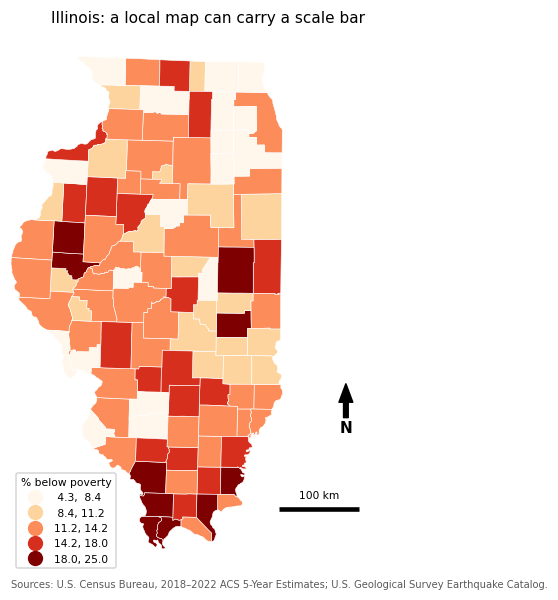

In [35]:
fig, ax = plt.subplots(figsize=(6.0, 6.4))
il_utm = il.to_crs(26916)                                           # UTM 16N, metres, built for this region
il_utm.plot(ax=ax, column="poverty_pct", scheme="NaturalBreaks", k=5, cmap="OrRd", edgecolor="white", lw=0.4,
            legend=True, legend_kwds={"fmt": "{:.1f}", "loc": "lower left", "fontsize": 7, "title": "% below poverty", "title_fontsize": 7})
x0, y0, x1, y1 = il_utm.total_bounds
ax.set_xlim(x0, x1 + 0.45 * (x1 - x0))                              # empty margin east of the state for map furniture
ax.set_axis_off(); add_scale_bar(ax, 100, x=0.68, y=0.12); add_north_arrow(ax, x=0.85, y=0.35)
ax.set_title("Illinois: a local map can carry a scale bar", fontsize=10); add_source(ax)
f = pyproj.Proj(26916).get_factors([-91.5, -87.5], [40, 40])
print("UTM 16N scale factor across Illinois:", np.round(f.meridional_scale, 4), "-> under 0.1 % error")
plt.show()

### 5.3 Turning data into symbols: vector (slide 31) and statistical diagrams (README 35–45′)
The same features can take different visual variables: **position** only, **size** (proportional to magnitude), and **colour value** (depth from the 3-D z coordinate).

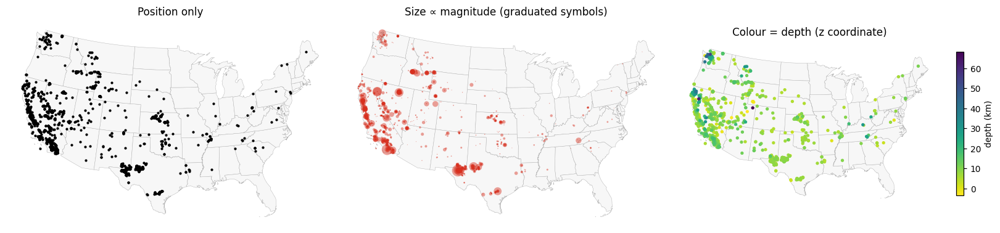

In [36]:
qp = quakes.to_crs(5070); qp = qp[qp.within(states48.union_all())]
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax in axes:
    states48.plot(ax=ax, color="#f7f7f7", edgecolor="0.7", lw=0.3); ax.set_axis_off()
qp.plot(ax=axes[0], markersize=3, color="k"); axes[0].set_title("Position only")
qp.plot(ax=axes[1], markersize=(qp.mag - 2) ** 3 * 4, color="#d7301f", alpha=0.45, lw=0)
axes[1].set_title("Size ∝ magnitude (graduated symbols)")
qp.sort_values("depth_km").plot(ax=axes[2], column="depth_km", cmap="viridis_r", markersize=6, legend=True,
                                legend_kwds={"shrink": 0.6, "label": "depth (km)"})
axes[2].set_title("Colour = depth (z coordinate)")
plt.tight_layout(); plt.show()

**Pie-chart diagrams (README 35–45′, QGIS *Layer Properties → Diagrams → Pie chart*).** Filter to one state first (Illinois, `state_fips = '17'`) so the 3,144 pies don't overlap. Pie size is scaled by total (√ so that **area** ∝ count).
Option A: race composition (`race_*`). Option B: commute mode (`commute_*`).

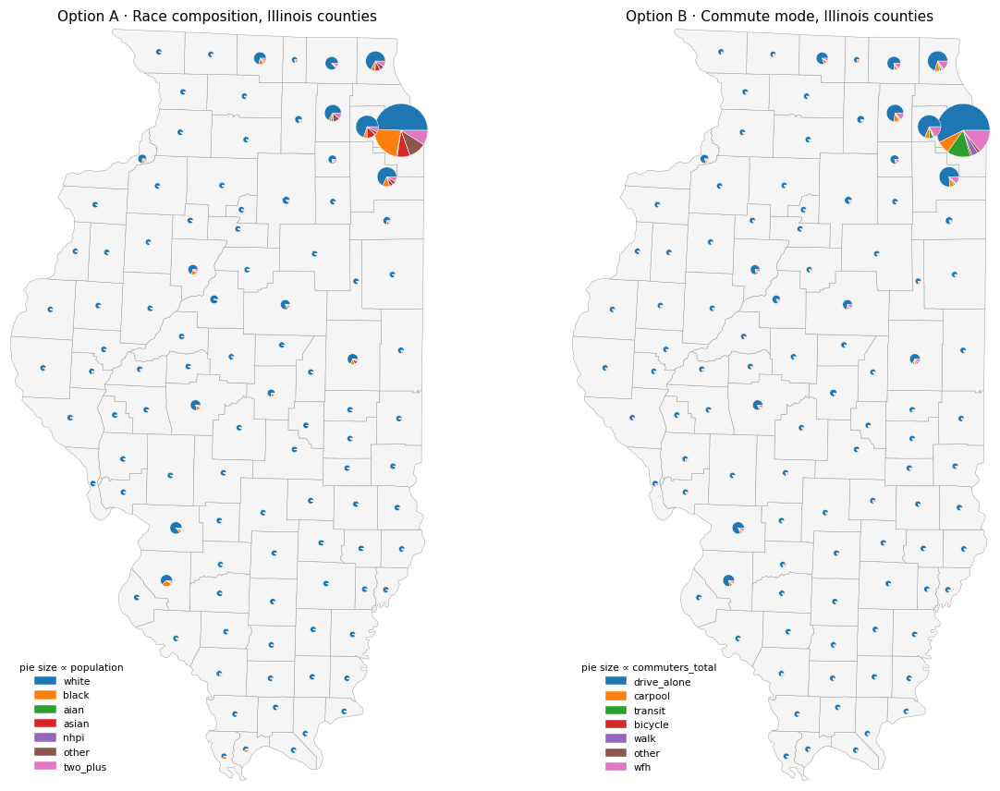

Reminder (README): pie area is not a percentage; state the size field and the class method in the map notes.


In [37]:
def pie_map(ax, gdf, fields, size_field, title, r_max=22_000):
    colors = plt.cm.tab10.colors[: len(fields)]          # fixed categorical order, never cycled
    gdf.plot(ax=ax, color="#f5f5f5", edgecolor="0.6", lw=0.3)
    pts = gdf.representative_point()
    for (_, rec), p in zip(gdf.iterrows(), pts):
        r = r_max * np.sqrt(rec[size_field] / gdf[size_field].max())
        ax.pie(rec[fields].astype(float), center=(p.x, p.y), radius=max(r, 2_500), colors=colors, frame=True,
               wedgeprops={"linewidth": 0.3, "edgecolor": "white"})
    x0, y0, x1, y1 = gdf.total_bounds
    ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_aspect("equal"); ax.set_axis_off()
    ax.legend([Patch(color=c) for c in colors], [f.split("_", 1)[1] for f in fields], loc="lower left",
              fontsize=7, frameon=False, title=f"pie size ∝ {size_field}", title_fontsize=7)
    ax.set_title(title, fontsize=10)


fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 8))
pie_map(a1, il_utm, race, "population", "Option A · Race composition, Illinois counties")
pie_map(a2, il_utm, commute, "commuters_total", "Option B · Commute mode, Illinois counties")
plt.tight_layout(); plt.show()
print("Reminder (README): pie area is not a percentage; state the size field and the class method in the map notes.")

**Generalisation (slide 31).** The same feature changes representation with scale: a county outline needs far fewer vertices on a national map than on a local one. Simplifying each polygon separately, as below, also opens slivers and gaps between neighbours — tools that keep shared borders (QGIS *Simplify* with care, or mapshaper) avoid that.
**QGIS:** *Vector → Geometry Tools → Simplify*.

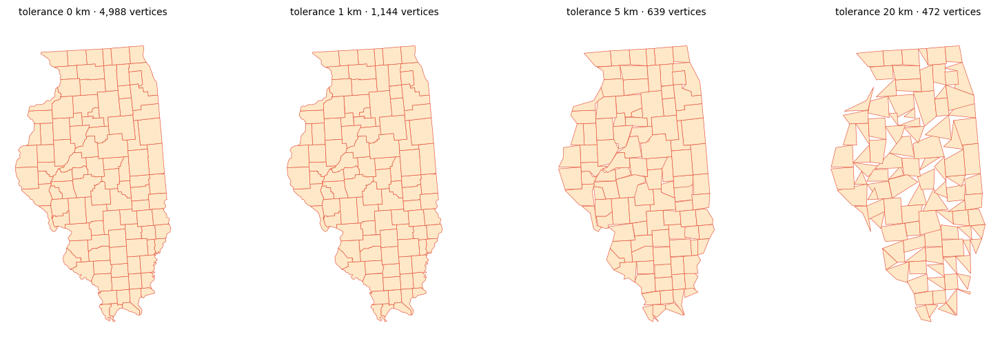

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.6))
for ax, tol in zip(axes, [0, 1_000, 5_000, 20_000]):
    g = il_m.copy(); g["geometry"] = il_m.simplify(tol) if tol else il_m.geometry
    nverts = int(g.geometry.count_coordinates().sum())
    g.plot(ax=ax, color="#fee8c8", edgecolor="#e34a33", lw=0.4)
    ax.set_title(f"tolerance {tol / 1000:g} km · {nverts:,} vertices", fontsize=9); ax.set_axis_off()
plt.tight_layout(); plt.show()

**Accessibility (slide 31): check colours for colour-blind readers.** About 1 in 12 men has a red–green colour-vision deficiency. The cell simulates deuteranopia (Machado et al. 2009) on three palettes: red-to-green ramps collapse, while viridis and red-blue stay distinguishable.

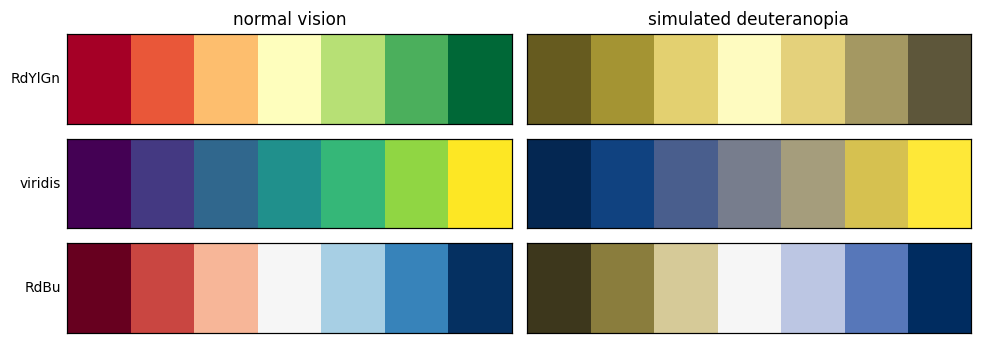

In [39]:
DEUTAN = np.array([[0.367322, 0.860646, -0.227968], [0.280085, 0.672501, 0.047413], [-0.011820, 0.042940, 0.968881]])


def simulate_deutan(rgb):
    lin = np.where(rgb <= 0.04045, rgb / 12.92, ((rgb + 0.055) / 1.055) ** 2.4)    # sRGB -> linear
    sim = np.clip(lin @ DEUTAN.T, 0, 1)
    return np.where(sim <= 0.0031308, sim * 12.92, 1.055 * sim ** (1 / 2.4) - 0.055)


fig, axes = plt.subplots(3, 2, figsize=(9, 3.2))
for row, name in enumerate(["RdYlGn", "viridis", "RdBu"]):
    sw = plt.get_cmap(name)(np.linspace(0, 1, 7))[None, :, :3]
    axes[row, 0].imshow(sw, aspect="auto"); axes[row, 1].imshow(simulate_deutan(sw), aspect="auto")
    axes[row, 0].set_ylabel(name, rotation=0, ha="right", va="center")
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([])
axes[0, 0].set_title("normal vision"); axes[0, 1].set_title("simulated deuteranopia")
plt.tight_layout(); plt.show()

### 5.4 Turning data into symbols: raster renderers (slide 32)
A **renderer** decides how cell values become colours. Slide 32 lists four, applied here to the real rasters:
- **RGB**: load three bands into the red, green and blue channels — natural colour (R,G,B) or false colour (NIR,R,G: vegetation turns red).
- **Unique values**: one colour per class — the land-cover raster carries its own NLCD colour table.
- **Stretch**: map a value range onto a colour ramp — the min–max range vs. a 2–98 % cut.
- **Classify**: group continuous values into classes — and different break choices give different maps.

**QGIS:** *Layer Properties → Symbology → Render type*: Multiband color / Paletted/Unique values / Singleband pseudocolor (Interpolation: Linear = stretch, Discrete = classify).

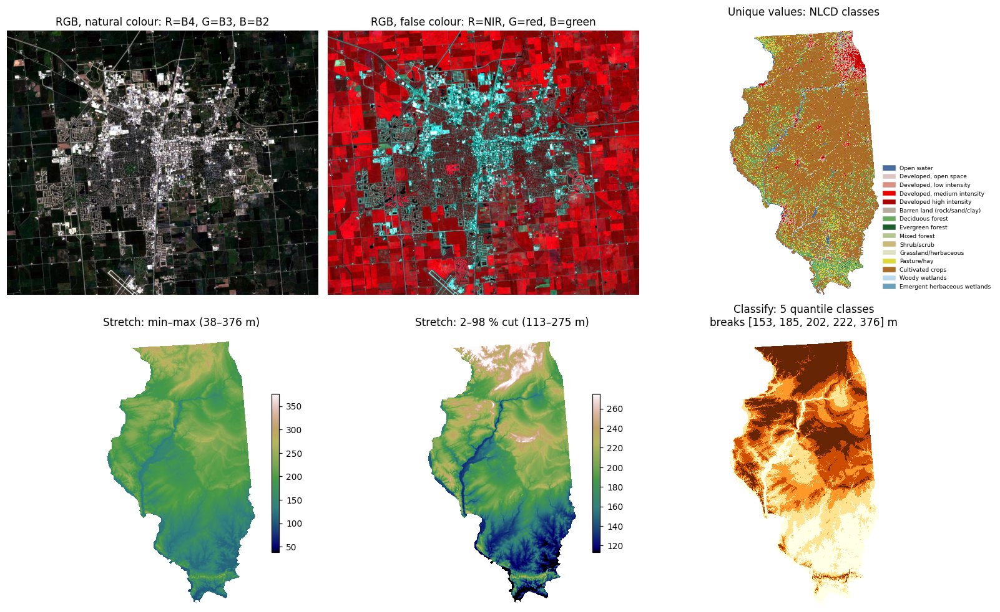

Equal-interval breaks for the same DEM: [106, 173, 241, 308, 376] m; cells per class: [51877, 1928365, 3893959, 602966, 7891] -> most of flat Illinois falls into 1-2 classes. A different decision shows a different landscape.


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9)); axes = axes.ravel()
axes[0].imshow(rgb_stretch([s2[0], s2[1], s2[2]]), extent=s2_ext); axes[0].set_title("RGB, natural colour: R=B4, G=B3, B=B2")
axes[1].imshow(rgb_stretch([s2[3], s2[0], s2[1]]), extent=s2_ext); axes[1].set_title("RGB, false colour: R=NIR, G=red, B=green")
axes[2].imshow(lut[nlcd.filled(0)], extent=nlcd_ext, interpolation="nearest"); axes[2].set_title("Unique values: NLCD classes")
present = [v for v in NLCD_VAT.value if v in set(np.unique(nlcd.compressed()))]
axes[2].legend([Patch(color=NLCD_CMAP[v]) for v in present], [NLCD_LABEL[v] for v in present], fontsize=6, loc="lower left",
               bbox_to_anchor=(1.0, 0.0), frameon=False)
im = axes[3].imshow(dem, extent=dem_ext, cmap="gist_earth", vmin=dem.min(), vmax=dem.max())
axes[3].set_title(f"Stretch: min–max ({dem.min():.0f}–{dem.max():.0f} m)"); fig.colorbar(im, ax=axes[3], shrink=0.6)
p2, p98 = np.percentile(dem.compressed(), [2, 98])
im = axes[4].imshow(dem, extent=dem_ext, cmap="gist_earth", vmin=p2, vmax=p98)
axes[4].set_title(f"Stretch: 2–98 % cut ({p2:.0f}–{p98:.0f} m)"); fig.colorbar(im, ax=axes[4], shrink=0.6)
dem_q = mc.Quantiles(dem.compressed(), k=5)
dem_eq = mc.EqualInterval(dem.compressed(), k=5)
axes[5].imshow(np.ma.masked_array(np.digitize(dem.filled(0), dem_q.bins[:-1]), dem.mask), extent=dem_ext,
               cmap=plt.get_cmap("YlOrBr", 5), interpolation="nearest")
axes[5].set_title(f"Classify: 5 quantile classes\nbreaks {np.round(dem_q.bins).astype(int).tolist()} m")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()
print("Equal-interval breaks for the same DEM:", np.round(dem_eq.bins).astype(int).tolist(), "m; cells per class:", dem_eq.counts.tolist(),
      "-> most of flat Illinois falls into 1-2 classes. A different decision shows a different landscape.")

### 5.5 Colour scheme: which palette carries the meaning (slide 33)
- **Quantitative** variables (house prices, temperature, rainfall) use a **sequential** ramp (one hue, light → dark), or a **diverging** ramp when there is a meaningful midpoint.
- **Qualitative** variables (building categories, regions) use a **qualitative** palette (distinct hues, no order).
- **Missing data** is shown as hatched grey with its own legend entry, never white (prompt template, slide 64).

The last panel is a counter-example: a rainbow ramp on a quantitative variable.

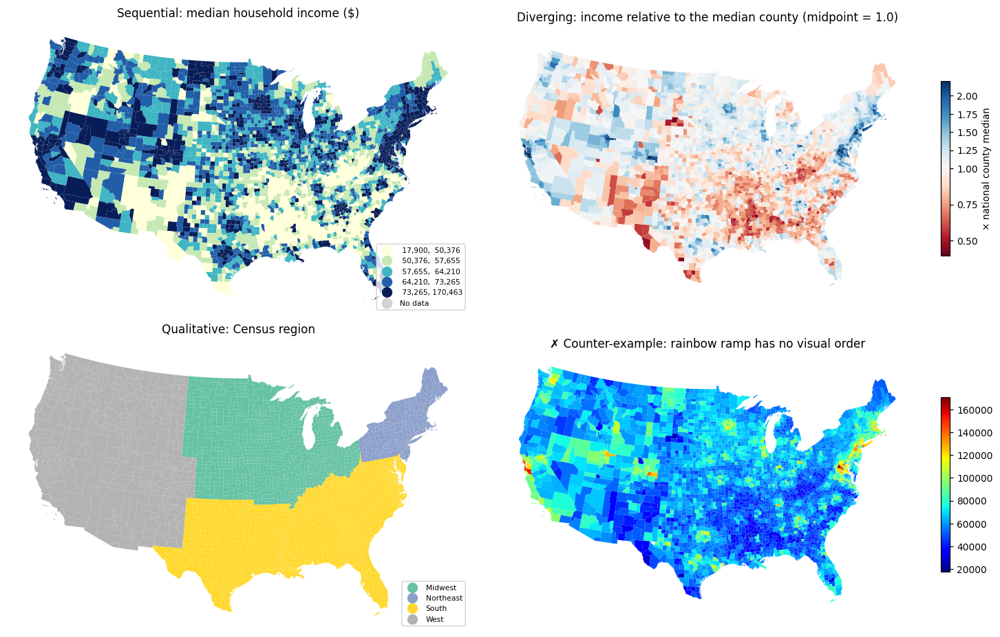

Missing (hatched) county: ['Loving County']


In [41]:
m = counties.copy()
m["income_vs_us"] = m.median_hh_income / m.median_hh_income.median()
m["region"] = m.state_abbr.map(REGION)
m48 = m[~m.state_abbr.isin(["AK", "HI"])].to_crs(5070)

fig, axes = plt.subplots(2, 2, figsize=(14, 8.5)); axes = axes.ravel()
m48.plot(ax=axes[0], column="median_hh_income", scheme="Quantiles", k=5, cmap="YlGnBu", lw=0, legend=True,
         missing_kwds=MISSING, legend_kwds={"fmt": "{:,.0f}", "loc": "lower right", "fontsize": 7})
axes[0].set_title("Sequential: median household income ($)")
m48.plot(ax=axes[1], column="income_vs_us", cmap="RdBu", norm=mpl.colors.TwoSlopeNorm(vmin=0.4, vcenter=1, vmax=2.2),
         lw=0, legend=True, missing_kwds=MISSING, legend_kwds={"shrink": 0.6, "label": "× national county median"})
axes[1].set_title("Diverging: income relative to the median county (midpoint = 1.0)")
m48.plot(ax=axes[2], column="region", categorical=True, cmap="Set2", lw=0, legend=True,
         legend_kwds={"loc": "lower right", "fontsize": 7})
axes[2].set_title("Qualitative: Census region")
m48.plot(ax=axes[3], column="median_hh_income", cmap="jet", lw=0, legend=True, legend_kwds={"shrink": 0.6})
axes[3].set_title("✗ Counter-example: rainbow ramp has no visual order")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()
print("Missing (hatched) county:", m.loc[m.median_hh_income.isna(), "county_label"].tolist())

### 5.6 Classification: equal interval vs quantile vs natural breaks (slide 34; README 10–25′)
Slide 34's figure was made from exactly this data (`outputs/make_classification_slide_figure.py`). **Darker = higher % below poverty** in every map.
**QGIS:** *Symbology → Graduated → 5 classes → Mode: Equal Interval / Quantile / Natural Breaks (Jenks).*
Record the break values for each method, then compare which counties change colour. Here natural breaks uses the exact Fisher–Jenks optimum; QGIS may sample the data for large layers, so its breaks can differ slightly.

,Equal interval,Quantile,Natural breaks (Jenks)
class 1 upper,12.4,9.3,10.0
class 2 upper,23.3,12.1,14.4
class 3 upper,34.1,14.9,19.3
class 4 upper,44.9,18.8,26.4
class 5 upper,55.8,55.8,55.8
class 1 n,1356.0,629.0,777.0
class 2 n,1543.0,629.0,1011.0
class 3 n,227.0,628.0,787.0
class 4 n,15.0,629.0,437.0
class 5 n,3.0,629.0,132.0


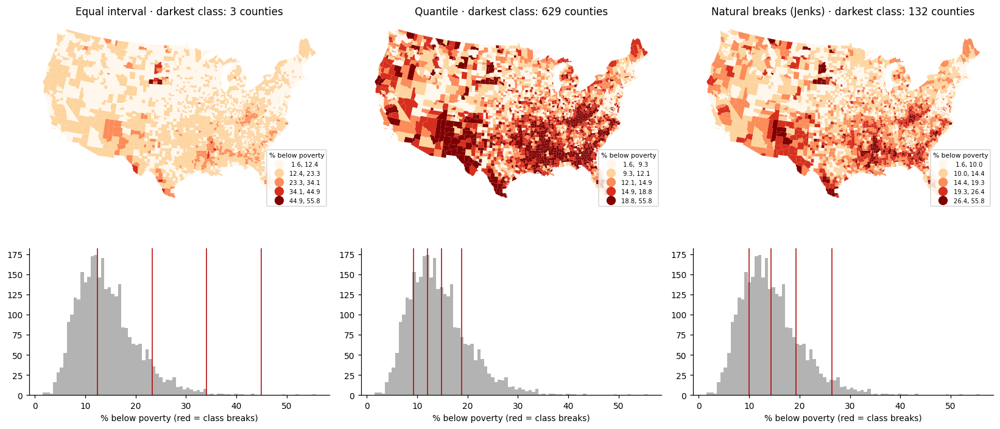

In [42]:
y = counties.poverty_pct
CLS = {"Equal interval": mc.EqualInterval(y, k=5), "Quantile": mc.Quantiles(y, k=5),
       "Natural breaks (Jenks)": mc.FisherJenks(y, k=5)}
breaks = pd.DataFrame({n: np.round(c.bins, 1) for n, c in CLS.items()}, index=[f"class {i+1} upper" for i in range(5)])
counts = pd.DataFrame({n: c.counts for n, c in CLS.items()}, index=[f"class {i+1} n" for i in range(5)])
display(pd.concat([breaks, counts]))

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), gridspec_kw={"height_ratios": [2.4, 1]})
for j, (n, c) in enumerate(CLS.items()):
    lower48.plot(ax=axes[0, j], column="poverty_pct", scheme="UserDefined", classification_kwds={"bins": list(c.bins)},
                 cmap="OrRd", lw=0, legend=True, legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "fontsize": 6.5,
                                                               "title": "% below poverty", "title_fontsize": 7})
    axes[0, j].set_title(f"{n} · darkest class: {c.counts[-1]} counties"); axes[0, j].set_axis_off()
    axes[1, j].hist(y, bins=80, color="0.7")
    for b in c.bins[:-1]:
        axes[1, j].axvline(b, color="#b30000", lw=1)
    axes[1, j].set_xlabel("% below poverty (red = class breaks)"); axes[1, j].spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

  Equal interval vs Quantile                :  2512 of 3144 counties change class
        Quantile vs Natural breaks (Jenks)  :  1804 of 3144 counties change class
  Equal interval vs Natural breaks (Jenks)  :  1932 of 3144 counties change class


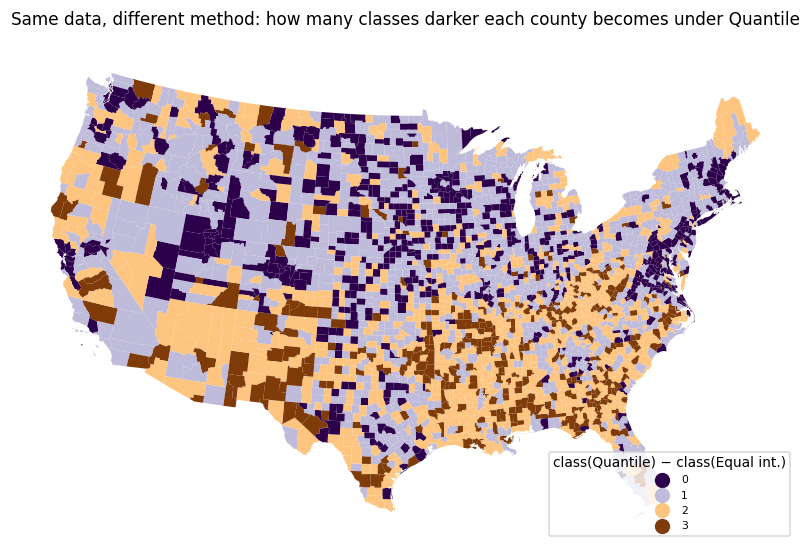

In [43]:
# Which counties change colour when only the method changes?
yb = pd.DataFrame({n: c.yb for n, c in CLS.items()}, index=counties.geoid)
for a, b in [("Equal interval", "Quantile"), ("Quantile", "Natural breaks (Jenks)"), ("Equal interval", "Natural breaks (Jenks)")]:
    print(f"{a:>16s} vs {b:<24s}: {(yb[a] != yb[b]).sum():5d} of {len(yb)} counties change class")

shift = lower48[["geoid", "geometry"]].merge((yb["Quantile"] - yb["Equal interval"]).rename("shift").reset_index(), on="geoid")
fig, ax = plt.subplots(figsize=(10, 5.8))
shift.plot(ax=ax, column="shift", categorical=True, cmap="PuOr_r", lw=0, legend=True,
           legend_kwds={"title": "class(Quantile) − class(Equal int.)", "loc": "lower right", "fontsize": 7})
ax.set_title("Same data, different method: how many classes darker each county becomes under Quantile"); ax.set_axis_off()
plt.show()

**Slide 34: "two Jenks maps are not comparable."** Natural breaks are fitted to *one* dataset. Compute them separately for two states and the same colour means different values:

In [44]:
rows = {}
for st in ["IL", "MS"]:
    rows[st] = np.round(mc.FisherJenks(counties.loc[counties.state_abbr == st, "poverty_pct"], k=5).bins, 1)
display(pd.DataFrame(rows, index=[f"class {i + 1} upper" for i in range(5)]))
print("Darkest class starts at", rows["IL"][3], "% in Illinois but at", rows["MS"][3], "% in Mississippi.",
      "Use one shared set of breaks (UserDefined) when maps are compared side by side.")

,IL,MS
class 1 upper,8.4,13.7
class 2 upper,11.2,19.6
class 3 upper,14.2,24.2
class 4 upper,18.0,29.3
class 5 upper,25.0,37.0


Darkest class starts at 18.0 % in Illinois but at 29.3 % in Mississippi. Use one shared set of breaks (UserDefined) when maps are compared side by side.


---
## 6 · Critical & Ethical Perspectives (slides 35–41)

Slide 36 lists four ways a map can "lie" without bad faith: **class breaks, colour direction, projection, normalisation**. Each one is reproduced below with this data, followed by moving breaks and omission (slide 37), redlining (slide 38), the MAUP (slide 39) and protective techniques (slide 40).

### 6.1 How maps "lie" (slide 36) — (a) class breaks: move a break and a place changes category

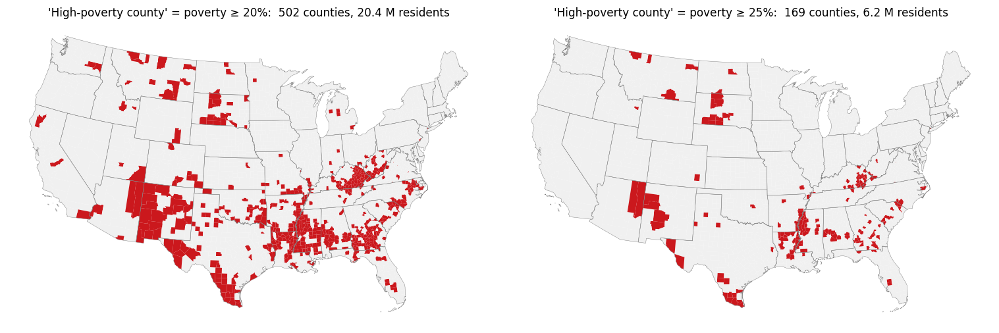

Moving the break from 20% to 25% drops 335 counties (14.3 M people) from the category.


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, t in zip(axes, [20, 25]):
    hi = lower48.poverty_pct >= t
    lower48.plot(ax=ax, color=np.where(hi, "#cb181d", "#f0f0f0"), lw=0)
    states48.boundary.plot(ax=ax, color="0.5", lw=0.3)
    pop = lower48.loc[hi, "population"].sum() / 1e6
    ax.set_title(f"'High-poverty county' = poverty ≥ {t}%:  {hi.sum()} counties, {pop:.1f} M residents"); ax.set_axis_off()
plt.tight_layout(); plt.show()
moved = counties[(counties.poverty_pct >= 20) & (counties.poverty_pct < 25)]
print(f"Moving the break from 20% to 25% drops {len(moved)} counties ({moved.population.sum()/1e6:.1f} M people) from the category.")

**(b) Colour direction: reverse the ramp, reverse the message**

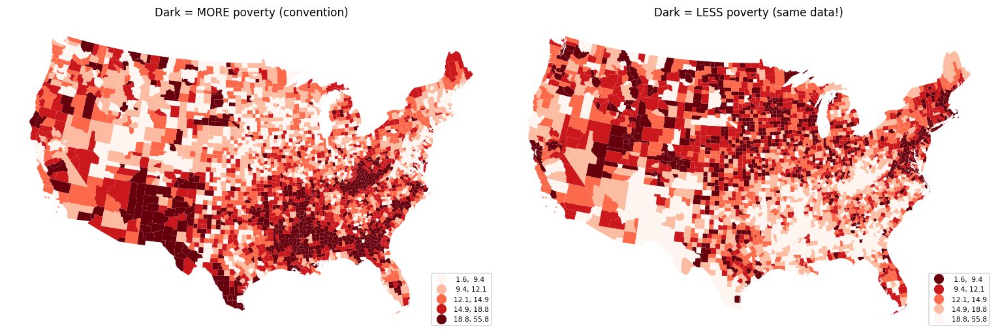

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, cmap, ttl in [(axes[0], "Reds", "Dark = MORE poverty (convention)"), (axes[1], "Reds_r", "Dark = LESS poverty (same data!)")]:
    lower48.plot(ax=ax, column="poverty_pct", scheme="Quantiles", k=5, cmap=cmap, lw=0, legend=True,
                 legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "fontsize": 7})
    ax.set_title(ttl); ax.set_axis_off()
plt.tight_layout(); plt.show()

**(c) Projection: inflate or shrink whole regions**
How much of the map's ink does Alaska take, compared with its true share of U.S. area?

In [47]:
rows = []
for name, crs in [("true (EPSG:6933 equal-area)", 6933), ("EPSG:3857 Web Mercator", 3857), ("EPSG:5070 Albers", 5070), ("EPSG:4269 Plate Carrée", 4269)]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        a = states.to_crs(crs).set_index("state_abbr").area
    rows.append({"projection": name, "Alaska share of map area": f"{100 * a['AK'] / a.sum():.1f}%",
                 "lower-48 share": f"{100 * a.drop(['AK', 'HI']).sum() / a.sum():.1f}%"})
display(pd.DataFrame(rows).set_index("projection"))

,Alaska share of map area,lower-48 share
projection,,
true (EPSG:6933 equal-area),16.3%,83.5%
EPSG:3857 Web Mercator,38.2%,61.7%
EPSG:5070 Albers,16.3%,83.5%
EPSG:4269 Plate Carrée,25.6%,74.3%


**(d) Normalisation: totals vs rates tell opposite stories** (README 10–25′ step 4)
Compare `population` with `pop_density_km2`, and `below_poverty` (count) with `poverty_pct` (rate).

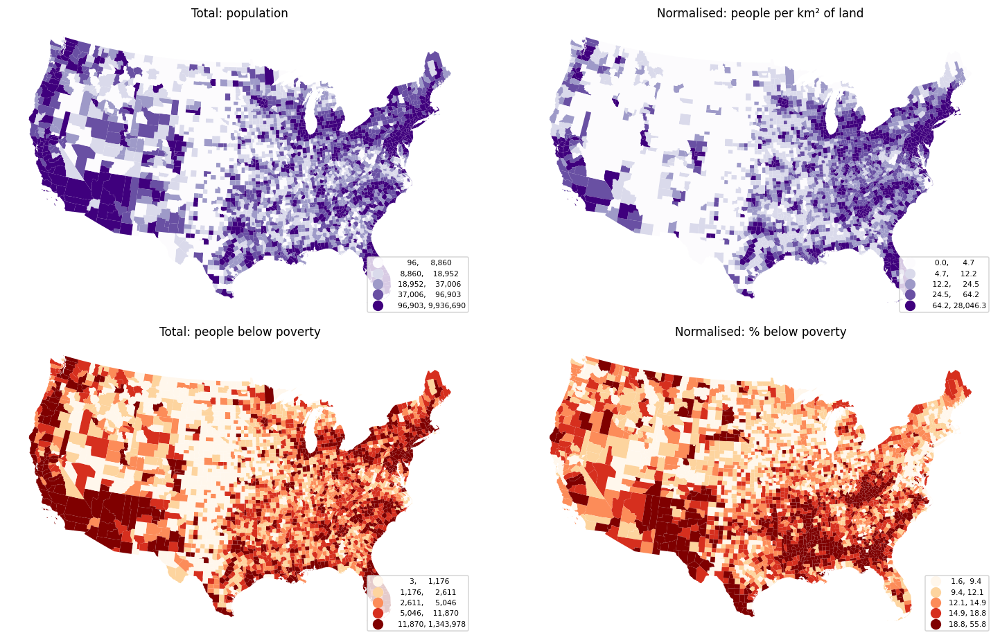

,Top 10 by count below poverty,Top 10 by % below poverty
0,"Los Angeles County, CA","Oglala Lakota County, SD"
1,"Harris County, TX","Todd County, SD"
2,"Cook County, IL","Mellette County, SD"
3,"Maricopa County, AZ","Dimmit County, TX"
4,"Kings County, NY","Corson County, SD"
5,"Miami-Dade County, FL","Ziebach County, SD"
6,"Bronx County, NY","East Carroll Parish, LA"
7,"Dallas County, TX","Presidio County, TX"
8,"Wayne County, MI","Sioux County, ND"
9,"Philadelphia County, PA","Jackson County, SD"


Overlap between the two top-10 lists: 0


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5)); axes = axes.ravel()
for ax, col, cmap, ttl in [(axes[0], "population", "Purples", "Total: population"),
                           (axes[1], "pop_density_km2", "Purples", "Normalised: people per km² of land"),
                           (axes[2], "below_poverty", "OrRd", "Total: people below poverty"),
                           (axes[3], "poverty_pct", "OrRd", "Normalised: % below poverty")]:
    lower48.plot(ax=ax, column=col, scheme="Quantiles", k=5, cmap=cmap, lw=0, legend=True,
                 legend_kwds={"fmt": "{:,.0f}" if col in ("population", "below_poverty") else "{:,.1f}",
                              "loc": "lower right", "fontsize": 7})
    ax.set_title(ttl); ax.set_axis_off()
plt.tight_layout(); plt.show()

top_n = lambda c: counties.nlargest(10, c).county_label.str.cat(counties.nlargest(10, c).state_abbr, sep=", ").tolist()
display(pd.DataFrame({"Top 10 by count below poverty": top_n("below_poverty"), "Top 10 by % below poverty": top_n("poverty_pct")}))
print("Overlap between the two top-10 lists:", len(set(top_n("below_poverty")) & set(top_n("poverty_pct"))))

### 6.2 The map and the mapping — distortion and omission (slide 37)
**Distortion over time.** Slide 37's Georgia COVID map *"looked like it was improving. It wasn't. The class breaks moved."* Quantile breaks are re-fitted to each new dataset, so a uniform change is invisible. Suppose every county became 3 points poorer:

In [49]:
y0 = counties.poverty_pct
y1 = y0 + 3                                                          # hypothetical: everyone 3 points worse
q0, q1 = mc.Quantiles(y0, k=5), mc.Quantiles(y1, k=5)
fixed = mc.UserDefined(y1, bins=list(q0.bins[:-1]) + [y1.max()])    # year-2 data, year-1 breaks
print("Quantile maps identical before and after?", bool((q0.yb == q1.yb).all()))
display(pd.DataFrame({"year 1 (quantile)": q0.counts, "year 2, breaks re-fitted": q1.counts, "year 2, year-1 breaks kept": fixed.counts},
                     index=[f"class {i + 1}" for i in range(5)]))

Quantile maps identical before and after? True


,year 1 (quantile),"year 2, breaks re-fitted","year 2, year-1 breaks kept"
class 1,629,629,133
class 2,629,629,437
class 3,628,628,642
class 4,629,629,840
class 5,629,629,1092


**Omission.** An incomplete map still looks complete. The world join in §3.6 left these countries without GDP data — some because of code conventions, some because of whose statehood is recognised (Taiwan is not in World Bank tables). On a choropleth they become grey shapes that are easy to overlook:

In [50]:
display(world.loc[world.gdp_pc_usd.isna(), ["NAME", "ISO_A3", "ISO_A3_EH", "CONTINENT"]].reset_index(drop=True))

,NAME,ISO_A3,ISO_A3_EH,CONTINENT
0,W. Sahara,ESH,ESH,Africa
1,Falkland Is.,FLK,FLK,South America
2,Fr. S. Antarctic Lands,ATF,ATF,Seven seas (open ocean)
3,Cuba,CUB,CUB,North America
4,North Korea,PRK,PRK,Asia
5,Taiwan,TWN,TWN,Asia
6,Eritrea,ERI,ERI,Africa
7,Yemen,YEM,YEM,Asia
8,Antarctica,ATA,ATA,Antarctica
9,N. Cyprus,-99,-99,Asia


### 6.3 Maps do not affect everyone equally — redlining (slide 38)
In the 1930s the Home Owners' Loan Corporation (HOLC) graded neighbourhoods A (green, "best") to D (red, "hazardous"); D areas were overwhelmingly Black. Aaronson et al. (2021) find D areas still have lower home values and higher poverty today. `vector/holc_chicago_1930s.shp` is the Chicago map from *Mapping Inequality* (University of Richmond).
**QGIS:** *Symbology → Categorized* on `grade`. (Before cleaning, the raw file had `"A "` and `"C "` with trailing spaces — QGIS would show them as extra categories.)

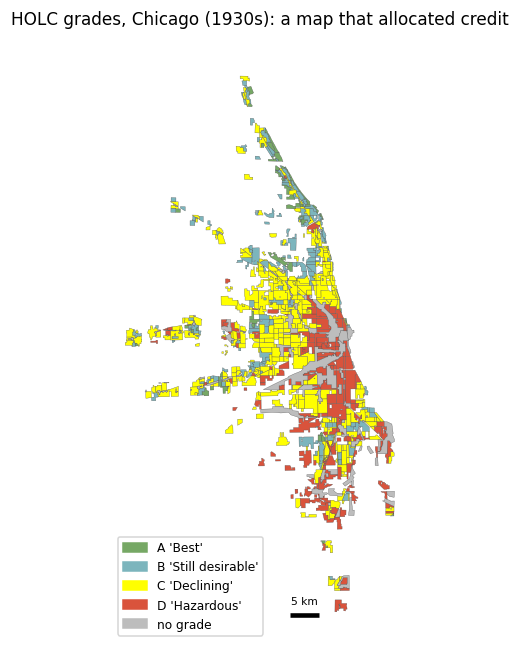

,% of graded area
grade,
A,4.4
B,17.0
C,51.5
D,27.1


In [51]:
holc = gpd.read_file(VEC / "holc_chicago_1930s.shp").to_crs(26916)
HOLC_COL = {"A": "#76a865", "B": "#7cb5bd", "C": "#ffff00", "D": "#d9533c"}
fig, ax = plt.subplots(figsize=(6.5, 7))
holc.plot(ax=ax, color=holc.grade.map(HOLC_COL).fillna("#bdbdbd"), edgecolor="0.3", lw=0.2)
ax.legend([Patch(color=v) for v in HOLC_COL.values()] + [Patch(color="#bdbdbd")],
          ["A 'Best'", "B 'Still desirable'", "C 'Declining'", "D 'Hazardous'", "no grade"], loc="lower left", fontsize=8)
ax.set_title("HOLC grades, Chicago (1930s): a map that allocated credit"); ax.set_axis_off()
add_scale_bar(ax, 5, x=0.6, y=0.04); plt.show()
share = holc.assign(km2=holc.area / 1e6).groupby("grade").km2.sum()
display((100 * share / share.sum()).round(1).rename("% of graded area").to_frame())

### 6.4 When the map is the policy: MAUP and gerrymandering (slide 39)
*Same people, different units, different results.* Two effects:
- **Scale effect:** county → state → Census region.
- **Zoning effect:** the same counties grouped into two 300 km grids that differ only by an offset.

Rates must be re-computed from counts (Σ below ÷ Σ universe). Averaging county percentages is a common mistake.

In [52]:
def aggregate(df, key):
    g = df.groupby(key).agg(below=("below_poverty", "sum"), universe=("poverty_universe", "sum"),
                            wfh=("commute_wfh", "sum"), workers=("commuters_total", "sum"),
                            naive_mean_pct=("poverty_pct", "mean"))
    g["poverty_pct"] = 100 * g.below / g.universe
    g["wfh_pct"] = 100 * g.wfh / g.workers
    return g


lw = lower48.copy()
cent = lw.representative_point()
lw["region"] = lw.state_abbr.map(REGION)
lw["grid_a"] = (cent.x // 300_000).astype(int).astype(str) + "_" + (cent.y // 300_000).astype(int).astype(str)
lw["grid_b"] = ((cent.x + 150_000) // 300_000).astype(int).astype(str) + "_" + ((cent.y + 150_000) // 300_000).astype(int).astype(str)

rows = []
for level in ["geoid", "grid_a", "grid_b", "state_abbr", "region"]:
    g = aggregate(lw, level)
    rows.append({"unit": level, "n units": len(g), "poverty % range": f"{g.poverty_pct.min():.1f} – {g.poverty_pct.max():.1f}",
                 "corr(poverty %, WFH %)": round(g[["poverty_pct", "wfh_pct"]].corr().iloc[0, 1], 2)})
display(pd.DataFrame(rows).set_index("unit"))

st = aggregate(lw, "state_abbr")
print(f"Illinois poverty: correct (Σbelow/Σuniverse) = {st.loc['IL', 'poverty_pct']:.1f}%  vs  naive mean of county % = {st.loc['IL', 'naive_mean_pct']:.1f}%")

,n units,poverty % range,"corr(poverty %, WFH %)"
unit,,,
geoid,3109,1.6 – 55.8,-0.37
grid_a,111,6.9 – 24.6,-0.55
grid_b,113,7.5 – 28.0,-0.51
state_abbr,49,7.3 – 19.2,-0.45
region,4,11.6 – 13.8,-0.50


Illinois poverty: correct (Σbelow/Σuniverse) = 11.8%  vs  naive mean of county % = 12.6%


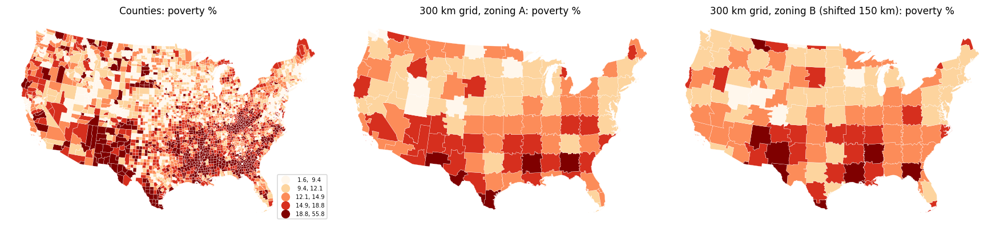

Ecological fallacy: the correlation in the table above changes with the unit, so county-level patterns say nothing certain about individuals.


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
bins = list(mc.Quantiles(lower48.poverty_pct, k=5).bins)
for ax, level, ttl in [(axes[0], "geoid", "Counties"), (axes[1], "grid_a", "300 km grid, zoning A"), (axes[2], "grid_b", "300 km grid, zoning B (shifted 150 km)")]:
    g = lw.dissolve(level)[["geometry"]].join(aggregate(lw, level)["poverty_pct"])
    g.plot(ax=ax, column="poverty_pct", scheme="UserDefined", classification_kwds={"bins": bins}, cmap="OrRd",
           edgecolor="white", lw=0.2, legend=(level == "geoid"), legend_kwds={"fmt": "{:.1f}", "loc": "lower right", "fontsize": 6.5})
    ax.set_title(f"{ttl}: poverty %"); ax.set_axis_off()
plt.tight_layout(); plt.show()
print("Ecological fallacy: the correlation in the table above changes with the unit, so county-level patterns say nothing certain about individuals.")

**Packing and cracking.** The same 100 voters (60 % blue, 40 % red) split into five equal districts of 20 three different ways. Only the district lines change:

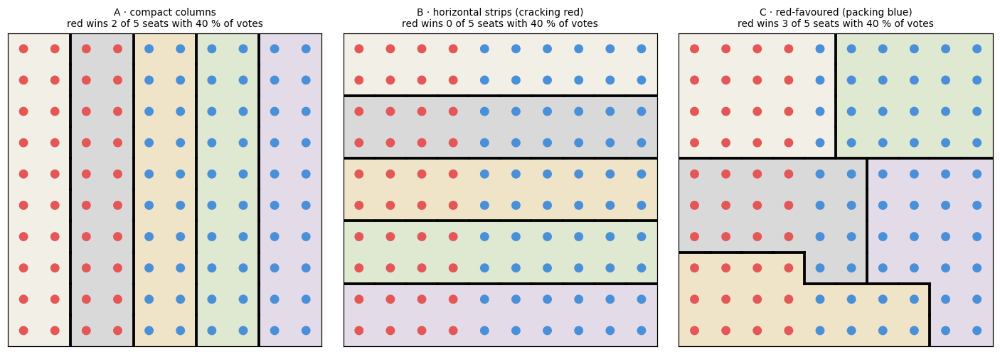

In [54]:
voters = np.zeros((10, 10), int); voters[:, :4] = 1                 # 1 = red (columns 0-3), 0 = blue
plans = {"A · compact columns": np.repeat(np.arange(5), 2)[None, :].repeat(10, 0),
         "B · horizontal strips (cracking red)": np.repeat(np.arange(5), 2)[:, None].repeat(10, 1)}
c = np.full((10, 10), -1)
c[0:4, 0:5] = 0                                                       # 16 red + 4 blue
c[4:7, 0:4] = 1; c[4:8, 4:6] = 1                                      # 12 red + 8 blue
c[7:10, 0:4] = 2; c[8:10, 4:8] = 2                                    # 12 red + 8 blue
c[0:4, 5:10] = 3                                                      # 20 blue (packed)
c[c == -1] = 4                                                        # 20 blue (packed)
plans["C · red-favoured (packing blue)"] = c
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (name, plan) in zip(axes, plans.items()):
    sizes = np.bincount(plan.ravel())
    assert (sizes == 20).all(), sizes
    red_share = np.array([voters[plan == d].mean() for d in range(5)])
    ax.imshow(plan, cmap=mpl.colors.ListedColormap(["#f2f0e6", "#d9d9d9", "#efe3c8", "#dfe8d0", "#e4dbe9"]))  # districts
    rr, cc = np.indices(voters.shape)
    ax.scatter(cc.ravel(), rr.ravel(), c=np.where(voters.ravel() == 1, "#e45756", "#4a90d9"), s=55)        # one dot per voter
    for (i, j), v in np.ndenumerate(plan):                           # district borders = edges between different districts
        if j + 1 < 10 and plan[i, j + 1] != v:
            ax.plot([j + .5, j + .5], [i - .5, i + .5], "k", lw=2.5)
        if i + 1 < 10 and plan[i + 1, j] != v:
            ax.plot([j - .5, j + .5], [i + .5, i + .5], "k", lw=2.5)
    ax.set_title(f"{name}\nred wins {int((red_share > 0.5).sum())} of 5 seats with 40 % of votes", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

### 6.5 Ethics: mapping vulnerable populations (slide 40)
Earthquakes are not sensitive, but the same techniques apply to refugee camps, shelters, or patient addresses. The cells below compare **exact points**, **jittered points** (random 5–25 km "donut" displacement), and **aggregation** to coarser units (counts per hexagon).

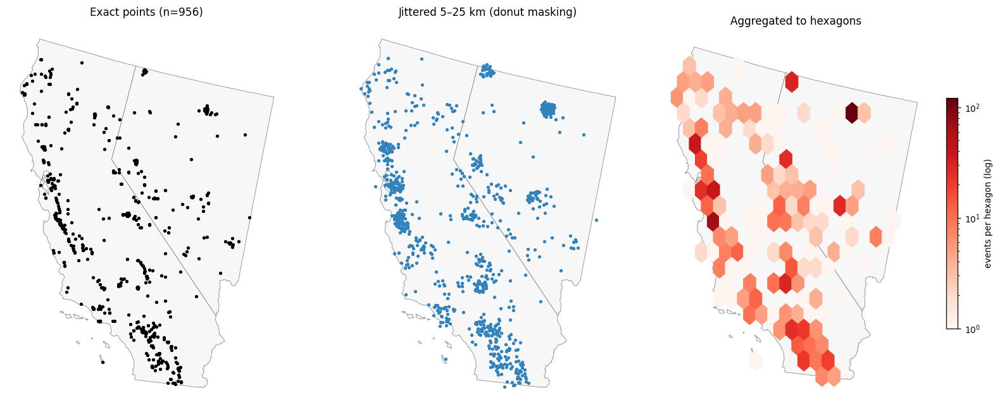

Ask before publishing: Who is on this map, and did they consent? Who could be harmed? Does aggregation keep the pattern?


In [55]:
ca = qp[qp.within(states48[states48.state_abbr.isin(["CA", "NV"])].union_all())].copy()
ang = RNG.uniform(0, 2 * np.pi, len(ca)); dist = RNG.uniform(5_000, 25_000, len(ca))
jit = ca.copy(); jit["geometry"] = gpd.points_from_xy(ca.geometry.x + dist * np.cos(ang), ca.geometry.y + dist * np.sin(ang), crs=5070)
base = states48[states48.state_abbr.isin(["CA", "NV"])]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax in axes:
    base.plot(ax=ax, color="#f7f7f7", edgecolor="0.5", lw=0.5); ax.set_axis_off()
ca.plot(ax=axes[0], markersize=6, color="k"); axes[0].set_title(f"Exact points (n={len(ca)})")
jit.plot(ax=axes[1], markersize=6, color="#3182bd"); axes[1].set_title("Jittered 5–25 km (donut masking)")
hb = axes[2].hexbin(ca.geometry.x, ca.geometry.y, gridsize=18, mincnt=1, cmap="Reds", bins="log")
fig.colorbar(hb, ax=axes[2], shrink=0.6, label="events per hexagon (log)"); axes[2].set_title("Aggregated to hexagons")
plt.tight_layout(); plt.show()
print("Ask before publishing: Who is on this map, and did they consent? Who could be harmed? Does aggregation keep the pattern?")

### 6.6 Feminist GIS & critical geography (slide 41)
No computation here — by design. Questions to carry from this notebook: which variables in the pack describe *paid* commuting but not care work (§5.3 pie charts)? What would a map of fear or belonging need that a county polygon cannot store? A "conscious design decision" includes deciding what **not** to map.

---
## 7 · Discussion (slides 42–43)
These slides are discussion only, with no data operations. Evidence from this notebook that you can bring to the small groups:
- **Kwan / feminist GIS:** what is *not* in this pack (care work, fear, mobility constraints)? The ACS commute categories record only the *main* mode of a *paid* worker (§5.3).
- **Snow, revisited:** §2.3 reads the earthquake points like Snow's pump map. Whose experience is missing when a point stands in for a person?
- **Visibility vs exposure:** §6.5 shows that jittering and aggregation keep the pattern while removing exact locations.

---
## 8 · Lab & Milestone (slides 44–45; workshop timeline slide 48)
| Slide 48 time | Step | Here |
|---|---|---|
| 0–10′ | load the shapefile, explore the attribute table | §1.1, §3.3 |
| 10–25′ | join attributes, build the choropleth (GDP per capita or climate risk) | §3.6 → **§8.1** |
| 25–40′ | ≥ 2 classification schemes, legend, colours, projection | §8.1, §5.6 |
| 40–50′ | export, workflow memo (200–300 words) | §8.1, §8.6 |
| 50–60′ | optional OSINT layer | §8.5 |

### 8.1 Workshop map: a world choropleth (slides 45, 48)
**QGIS:** join the two CSVs to `world_countries_ne110m.shp` on `ISO_A3_EH` (§3.6) → *Symbology → Graduated* on `gdp_pc_usd` → try two modes → *Project → Properties → CRS* = EPSG:8857 Equal Earth → *Project → New Print Layout* → export PNG/PDF.
GDP per capita is very skewed, so the class method matters even more than for U.S. poverty:

,Quantile,Natural breaks (Jenks)
class 1 upper,1700,10100
class 2 upper,4200,24900
class 3 upper,8300,41000
class 4 upper,29100,78000
class 5 upper,123700,123700


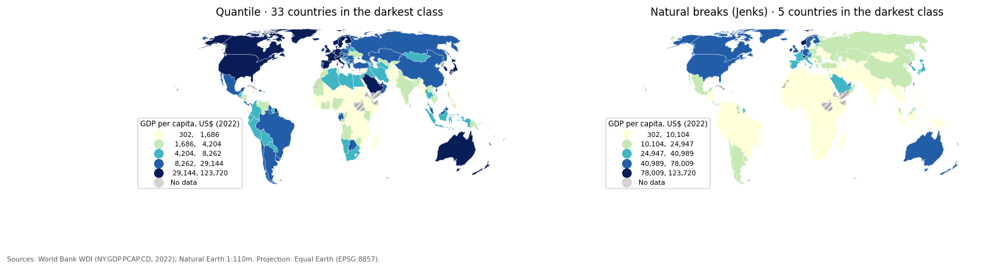

In [56]:
wmap = world[world.CONTINENT != "Antarctica"].to_crs(8857)                # Equal Earth: equal-area world projection
y = wmap.gdp_pc_usd.dropna()
SCHEMES = {"Quantile": mc.Quantiles(y, k=5), "Natural breaks (Jenks)": mc.FisherJenks(y, k=5)}
display(pd.DataFrame({n: np.round(c.bins, -2).astype(int) for n, c in SCHEMES.items()}, index=[f"class {i + 1} upper" for i in range(5)]))

fig, axes = plt.subplots(1, 2, figsize=(16, 4.6))
for ax, (n, cls) in zip(axes, SCHEMES.items()):
    wmap.plot(ax=ax, column="gdp_pc_usd", scheme="UserDefined", classification_kwds={"bins": list(cls.bins)}, cmap="YlGnBu",
              edgecolor="white", lw=0.2, missing_kwds=MISSING, legend=True,
              legend_kwds={"fmt": "{:,.0f}", "loc": "lower left", "fontsize": 7, "title": "GDP per capita, US$ (2022)", "title_fontsize": 7.5})
    ax.set_title(f"{n} · {cls.counts[-1]} countries in the darkest class"); ax.set_axis_off()
fig.text(0.01, 0.01, "Sources: World Bank WDI (NY.GDP.PCAP.CD, 2022); Natural Earth 1:110m. Projection: Equal Earth (EPSG:8857).",
         fontsize=7, color="0.35")
fig.savefig(OUT / "world_gdp_per_capita_2022.png", dpi=200, bbox_inches="tight"); plt.show()

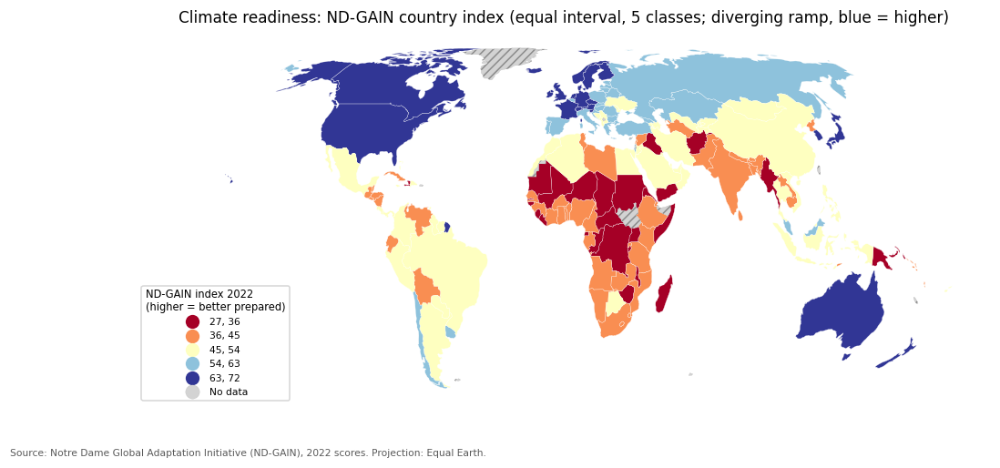

Spearman correlation GDP per capita vs ND-GAIN: 0.88


In [57]:
fig, ax = plt.subplots(figsize=(11, 5))
nd_bins = mc.EqualInterval(wmap.ndgain.dropna(), k=5).bins
wmap.plot(ax=ax, column="ndgain", scheme="UserDefined", classification_kwds={"bins": list(nd_bins)}, cmap="RdYlBu",
          edgecolor="white", lw=0.2, missing_kwds=MISSING, legend=True,
          legend_kwds={"fmt": "{:.0f}", "loc": "lower left", "fontsize": 7, "title": "ND-GAIN index 2022\n(higher = better prepared)", "title_fontsize": 7.5})
ax.set_title("Climate readiness: ND-GAIN country index (equal interval, 5 classes; diverging ramp, blue = higher)"); ax.set_axis_off()
fig.text(0.01, 0.02, "Source: Notre Dame Global Adaptation Initiative (ND-GAIN), 2022 scores. Projection: Equal Earth.", fontsize=7, color="0.35")
fig.savefig(OUT / "world_ndgain_2022.png", dpi=200, bbox_inches="tight"); plt.show()
print("Spearman correlation GDP per capita vs ND-GAIN:", round(wmap[["gdp_pc_usd", "ndgain"]].corr(method="spearman").iloc[0, 1], 2))

---
### 8.2 U.S. track: the AI map brief (prompt template, slide 64) and the final map
The prompt template (appendix slide 64), completed with decisions this notebook can defend. The final map follows it, and the code **prints the class breaks before rendering**, as the template requires.

In [58]:
BRIEF = {
    "purpose / audience / medium": "Show where poverty concentrates, for GLBL 570 classmates, on a letter-size slide",
    "message": "High poverty is regionally clustered (Delta, Appalachia, border, reservations), not random",
    "layer": "us_counties_acs2022, U.S. Census Bureau ACS 2018–22, polygon, EPSG:4269",
    "unit of analysis": "county (do not change it)",
    "variable": "poverty_pct = below_poverty / poverty_universe (already normalised: a rate, not a count)",
    "classification": "Natural breaks (Fisher–Jenks), 5 classes",
    "colour": "sequential OrRd, colour-blind safe, dark = high",
    "missing data": "hatched grey with its own legend entry",
    "projection": "EPSG:5070 Conus Albers (equal-area, because colour fills area); AK/HI insets in their own Albers",
    "marginalia": "title, subtitle, source, CRS note, scale bar; no north arrow (north rotates across a conic map)",
    "do not": "invent data to fill gaps",
}
for k, v in BRIEF.items():
    print(f"- {k}: {v}")

final_bins = mc.FisherJenks(counties.poverty_pct.dropna(), k=5).bins
print("\nBreak values BEFORE rendering:", np.round(final_bins, 1))

- purpose / audience / medium: Show where poverty concentrates, for GLBL 570 classmates, on a letter-size slide
- message: High poverty is regionally clustered (Delta, Appalachia, border, reservations), not random
- layer: us_counties_acs2022, U.S. Census Bureau ACS 2018–22, polygon, EPSG:4269
- unit of analysis: county (do not change it)
- variable: poverty_pct = below_poverty / poverty_universe (already normalised: a rate, not a count)
- classification: Natural breaks (Fisher–Jenks), 5 classes
- colour: sequential OrRd, colour-blind safe, dark = high
- missing data: hatched grey with its own legend entry
- projection: EPSG:5070 Conus Albers (equal-area, because colour fills area); AK/HI insets in their own Albers
- marginalia: title, subtitle, source, CRS note, scale bar; no north arrow (north rotates across a conic map)
- do not: invent data to fill gaps

Break values BEFORE rendering: [10.  14.4 19.3 26.4 55.8]


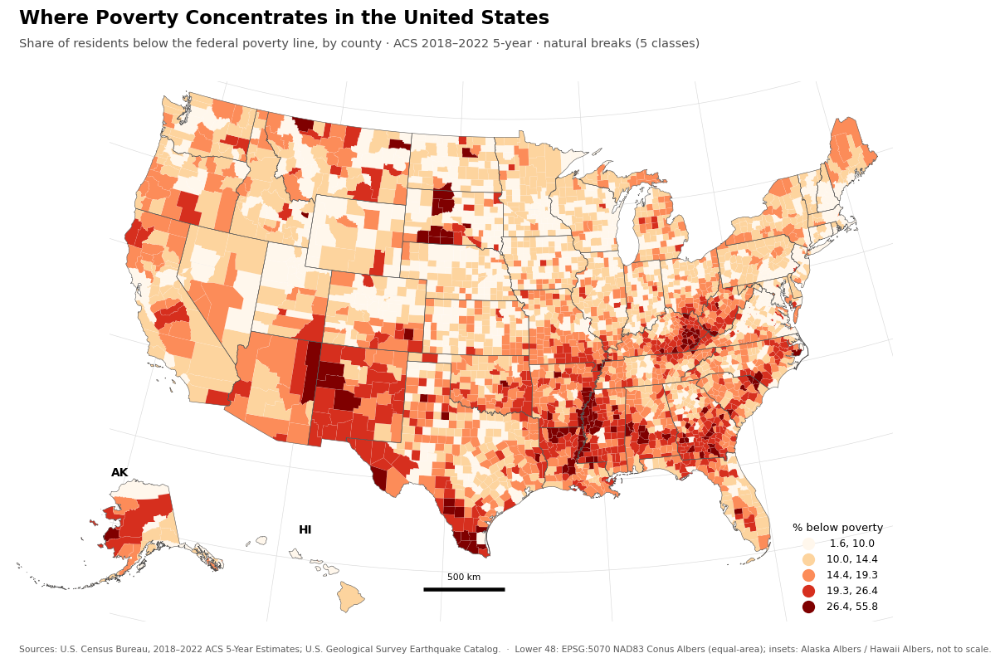

Exported: ['final_map_poverty_pct.pdf', 'final_map_poverty_pct.png']


In [59]:
us_choropleth(counties, "poverty_pct", final_bins, "OrRd",
              "Where Poverty Concentrates in the United States",
              "Share of residents below the federal poverty line, by county · ACS 2018–2022 5-year · natural breaks (5 classes)",
              "% below poverty", fname="final_map_poverty_pct")
plt.show()
print("Exported:", sorted(p.name for p in OUT.glob("final_map_poverty_pct.*")))

### 8.3 Bringing other data in: spatial join of CSV points and zonal statistics of rasters
Not everything arrives as a Shapefile with the right attributes. Two routes bring outside data onto the county polygons:

**(a) Points from a CSV → spatial join (summary).** The earthquake table (§3.6, geocoded from lat/lon) is joined to counties by location.
**QGIS:** *Processing Toolbox → Join attributes by location (summary)*: input = counties, join = the delimited-text point layer, predicate = *intersects*, summaries = count / mean / max of `mag`. Then normalise the count to **events per 10,000 km²**.

In [60]:
eq_nad83 = eq_pts.to_crs(counties.crs)                                       # CSV points (WGS 84) -> NAD83 first
pairs = gpd.sjoin(eq_nad83[["mag", "geometry"]], counties[["geoid", "geometry"]], predicate="intersects", how="inner")
summary = pairs.groupby("geoid").mag.agg(mag_count="count", mag_mean="mean", mag_max="max")
eq = counties.merge(summary, on="geoid", how="left")
eq["mag_count"] = eq.mag_count.fillna(0).astype(int)                      # no quake = 0, a real value (not missing)
eq["eq_per_10k_km2"] = eq.mag_count / (eq.land_km2 + eq.water_km2) * 1e4

print(f"Points joined: {len(pairs)} (CSV has {len(eq_nad83)}; {pairs.index.duplicated().sum()} points touch >1 county)")
print(f"Counties with ≥1 event: {(eq.mag_count > 0).sum()} of {len(eq)}")
display(eq.nlargest(8, "mag_count")[["county_label", "state_abbr", "mag_count", "mag_mean", "mag_max", "eq_per_10k_km2"]].round(2))
display(eq.nlargest(8, "eq_per_10k_km2")[["county_label", "state_abbr", "mag_count", "eq_per_10k_km2"]].round(2))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    eq.to_file(OUT / "lab_outputs.gpkg", layer="counties_eq_summary_2025")

Points joined: 3290 (CSV has 3754; 0 points touch >1 county)
Counties with ≥1 event: 263 of 3144


,county_label,state_abbr,mag_count,mag_mean,mag_max,eq_per_10k_km2
3099,Matanuska-Susitna Borough,AK,273,2.88,6.0,41.72
1128,Culberson County,TX,262,2.84,5.4,265.34
788,Kenai Peninsula Borough,AK,248,2.86,5.4,38.73
845,Hawaii County,HI,134,2.87,4.4,101.72
1866,Elko County,NV,127,3.02,4.8,28.50
2030,Denali Borough,AK,106,2.92,4.1,32.31
347,Custer County,ID,100,2.94,4.3,78.18
384,Yukon-Koyukuk Census Area,AK,82,2.93,5.2,2.14


,county_label,state_abbr,mag_count,eq_per_10k_km2
1128,Culberson County,TX,262,265.34
1548,Contra Costa County,CA,46,220.93
1401,San Benito County,CA,70,194.37
41,Martin County,TX,45,189.74
2058,Loving County,TX,26,148.38
2060,Broomfield County,CO,1,115.09
1497,Sonoma County,CA,49,107.05
2774,Alameda County,CA,22,103.44


**Why do some points not join?** The README says the points were clipped to the county boundaries, yet the *intersects* join leaves some unmatched. The cell below measures how far those points lie from the nearest county polygon.

In [61]:
lost = eq_nad83[~eq_nad83.index.isin(pairs.index)]
near = gpd.sjoin_nearest(lost.to_crs(5070), counties[["geoid", "state_abbr", "geometry"]].to_crs(5070), distance_col="dist_m")
print(f"{len(lost)} unjoined events; by state of nearest county: {near.state_abbr.value_counts().to_dict()}")
print(f"distance to nearest county polygon: median {near.dist_m.median()/1000:.1f} km, max {near.dist_m.max()/1000:.1f} km")
print("They are real events in coastal water (Alaska and Hawaii shores) that fall outside the generalised 1:5,000,000")
print("shoreline (slide 61, stage 5 'Scale'; Appendix A.7). An 'intersects' join silently drops them. Report this or use a nearest join")
print("with a stated distance limit, but do not hide it.")

464 unjoined events; by state of nearest county: {'AK': 425, 'HI': 21, 'CA': 17, 'ME': 1}
distance to nearest county polygon: median 3.8 km, max 43.6 km
They are real events in coastal water (Alaska and Hawaii shores) that fall outside the generalised 1:5,000,000
shoreline (slide 61, stage 5 'Scale'; Appendix A.7). An 'intersects' join silently drops them. Report this or use a nearest join
with a stated distance limit, but do not hide it.


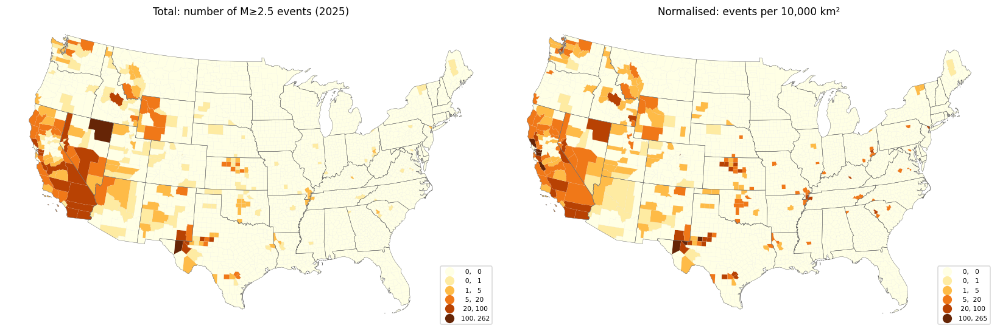

Alaska holds 36% of all joined events, but the lower-48 map above cannot show it.
Selection bias: one year (2025) and a M≥2.5 cut-off; this is not long-term seismic hazard (README).


In [62]:
eq48 = eq[~eq.state_abbr.isin(["AK", "HI"])].to_crs(5070)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col, bins, ttl in [(axes[0], "mag_count", [0, 1, 5, 20, 100, eq48.mag_count.max()], "Total: number of M≥2.5 events (2025)"),
                           (axes[1], "eq_per_10k_km2", [0, 1, 5, 20, 100, eq48.eq_per_10k_km2.max()], "Normalised: events per 10,000 km²")]:
    eq48.plot(ax=ax, column=col, scheme="UserDefined", classification_kwds={"bins": bins}, cmap="YlOrBr",
              edgecolor="0.85", lw=0.05, legend=True, legend_kwds={"fmt": "{:.0f}", "loc": "lower right", "fontsize": 7})
    states48.boundary.plot(ax=ax, color="0.4", lw=0.3); ax.set_title(ttl); ax.set_axis_off()
plt.tight_layout(); plt.show()
ak_share = eq.loc[eq.state_abbr == "AK", "mag_count"].sum() / eq.mag_count.sum()
print(f"Alaska holds {100*ak_share:.0f}% of all joined events, but the lower-48 map above cannot show it.")
print("Selection bias: one year (2025) and a M≥2.5 cut-off; this is not long-term seismic hazard (README).")

**(b) Raster → zonal statistics.** A raster has no attribute table to join, so its cells are summarised *inside each polygon* instead. Here WorldPop's modelled population is summed per Illinois county and compared with the ACS survey count, and the land-cover raster gives each county's **% developed** (NLCD classes 21–24).
**QGIS:** *Processing Toolbox → Zonal statistics* (input = county layer, raster = `illinois_worldpop_2020_1km.tif`, statistic = Sum; for land cover use *Zonal histogram*). Both rasters are in EPSG:5070, so the counties are reprojected to match first.

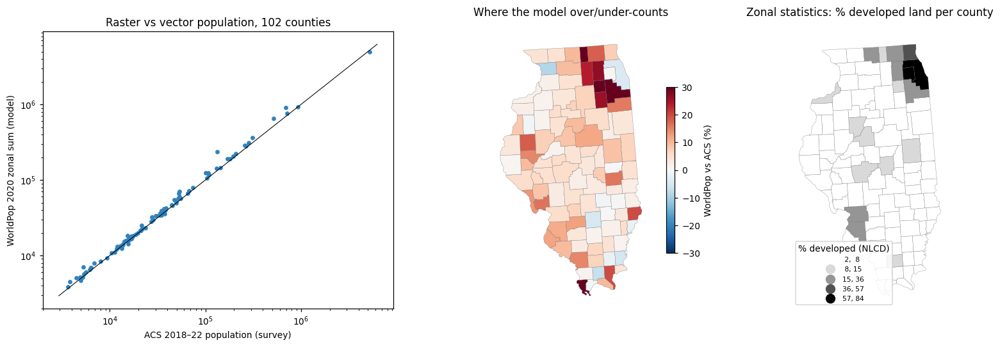

Illinois total: WorldPop 13,412,445 vs ACS 12,757,634 (+5.1 %). Median county difference +4.6 %.
Spearman(% developed, pop density): 0.94


In [63]:
def zone_raster(gdf, prof):
    # Burn polygon index into the raster grid: each cell belongs to the county containing its centre.
    shapes = ((geom, i + 1) for i, geom in enumerate(gdf.geometry))
    return features.rasterize(shapes, out_shape=(prof["height"], prof["width"]), transform=prof["transform"], fill=0, dtype="int32")


ilz = il.to_crs(5070).reset_index(drop=True)
z_wp = zone_raster(ilz, wp_prof)
wp_sum = np.bincount(z_wp.ravel(), weights=wp.filled(0).ravel(), minlength=len(ilz) + 1)[1:]
ilz["worldpop_2020"] = wp_sum
ilz["diff_pct"] = 100 * (ilz.worldpop_2020 / ilz.population - 1)

z_lc = zone_raster(ilz, nlcd_prof)
lc = nlcd.filled(0)
dev = np.isin(lc, [21, 22, 23, 24])
ilz["developed_pct"] = 100 * np.bincount(z_lc.ravel(), weights=dev.ravel(), minlength=len(ilz) + 1)[1:] / \
                       np.bincount(z_lc.ravel(), weights=(lc > 0).ravel(), minlength=len(ilz) + 1)[1:]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(ilz.population, ilz.worldpop_2020, s=12, color="#3182bd")
lim = [ilz.population.min() * 0.8, ilz.population.max() * 1.2]; axes[0].plot(lim, lim, color="k", lw=0.7)
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_xlabel("ACS 2018–22 population (survey)")
axes[0].set_ylabel("WorldPop 2020 zonal sum (model)"); axes[0].set_title("Raster vs vector population, 102 counties")
ilz.plot(ax=axes[1], column="diff_pct", cmap="RdBu_r", norm=mpl.colors.TwoSlopeNorm(vcenter=0, vmin=-30, vmax=30),
         edgecolor="0.4", lw=0.2, legend=True, legend_kwds={"shrink": 0.6, "label": "WorldPop vs ACS (%)"})
axes[1].set_title("Where the model over/under-counts"); axes[1].set_axis_off()
ilz.plot(ax=axes[2], column="developed_pct", scheme="NaturalBreaks", k=5, cmap="Greys", edgecolor="0.4", lw=0.2,
         legend=True, legend_kwds={"fmt": "{:.0f}", "loc": "lower left", "fontsize": 7, "title": "% developed (NLCD)"})
axes[2].set_title("Zonal statistics: % developed land per county"); axes[2].set_axis_off()
plt.tight_layout(); plt.show()
print(f"Illinois total: WorldPop {ilz.worldpop_2020.sum():,.0f} vs ACS {ilz.population.sum():,.0f} "
      f"({100 * (ilz.worldpop_2020.sum() / ilz.population.sum() - 1):+.1f} %). Median county difference {ilz.diff_pct.median():+.1f} %.")
print("Spearman(% developed, pop density):", round(ilz[["developed_pct", "pop_density_km2"]].corr(method="spearman").iloc[0, 1], 2))

### 8.4 Optional: Global Moran's I and LISA for `poverty_pct` (README "further analysis")
This is the formal test of the "poverty clusters" seen in §2.2 (and appendix slide 51). It uses **queen contiguity** (counties sharing a border or a corner) on the lower 48, row-standardised weights, and 999 permutations.
PySAL (`libpysal`/`esda`) is not installed here, so the statistics are computed directly with numpy/scipy. The formulas match PySAL's. GeoDa can open `lab_data/vector/us_counties_acs2022.shp` to cross-check.

In [64]:
from scipy import sparse

c48 = lower48[["geoid", "county_label", "state_abbr", "poverty_pct", "geometry"]].reset_index(drop=True)
nb = gpd.sjoin(c48[["geometry"]], c48[["geometry"]], predicate="intersects")
nb = nb[nb.index != nb.index_right]
islands = sorted(set(c48.index) - set(nb.index))
print("Counties with no neighbours (dropped):", c48.loc[islands, "county_label"].str.cat(c48.loc[islands, "state_abbr"], sep=", ").tolist())
keep = np.setdiff1d(c48.index, islands)
c48 = c48.loc[keep].reset_index(drop=True)
remap = {old: new for new, old in enumerate(keep)}
i, j = nb.index.map(remap), nb.index_right.map(remap)
ok = ~(pd.isna(i) | pd.isna(j))
Wb = sparse.csr_matrix((np.ones(ok.sum()), (np.asarray(i[ok], int), np.asarray(j[ok], int))), shape=(len(c48),) * 2)
k = np.asarray(Wb.sum(1)).ravel()
W = sparse.diags(1 / k) @ Wb                                   # row-standardised

z = c48.poverty_pct.values - c48.poverty_pct.mean()
n = len(z)
moran_I = (z @ (W @ z)) / (z @ z)                              # S0 = n under row standardisation
perms = np.column_stack([RNG.permutation(z) for _ in range(999)])
I_sim = np.einsum("ij,ij->j", perms, W @ perms) / (perms ** 2).sum(0)
p_sim = (np.sum(I_sim >= moran_I) + 1) / 1000
print(f"Global Moran's I = {moran_I:.3f}  (E[I] = {-1/(n-1):.4f}),  pseudo p = {p_sim:.3f}  (n = {n}, mean neighbours = {k.mean():.1f})")

Counties with no neighbours (dropped): ['Nantucket County, MA', 'San Juan County, WA']
Global Moran's I = 0.496  (E[I] = -0.0003),  pseudo p = 0.001  (n = 3107, mean neighbours = 5.8)


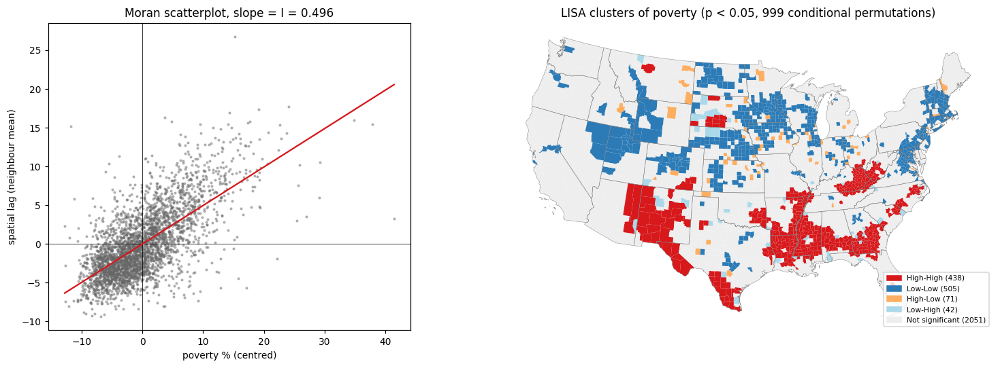

Caveat: p < 0.05 for ~3,100 local tests with no multiple-testing correction; expect some false positives.


In [65]:
# Local Moran (LISA) with conditional permutation. Neighbour values are drawn with replacement
# from the other n-1 counties, an approximation that is negligible here because k << n.
m2 = (z @ z) / n
lag = W @ z
Ii = z * lag / m2
kk = np.asarray(Wb.sum(1)).ravel().astype(int)
p_local = np.empty(n)
for idx in range(n):
    draw = RNG.integers(0, n - 1, size=(999, kk[idx]))
    draw[draw >= idx] += 1                                     # skip the county itself
    sim = z[idx] * z[draw].mean(1) / m2
    larger = (sim >= Ii[idx]).sum()
    p_local[idx] = (min(larger, 999 - larger) + 1) / 1000

quad = np.select([(z > 0) & (lag > 0), (z < 0) & (lag < 0), (z > 0) & (lag < 0), (z < 0) & (lag > 0)], ["High-High", "Low-Low", "High-Low", "Low-High"], default="")   # string default: required by NumPy >= 2
c48["lisa"] = np.where(p_local < 0.05, quad, "Not significant")
LISA_COL = {"High-High": "#d7191c", "Low-Low": "#2c7bb6", "High-Low": "#fdae61", "Low-High": "#abd9e9", "Not significant": "#eeeeee"}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 2]})
a1.scatter(z, lag, s=3, alpha=0.4, color="0.4"); a1.axhline(0, color="k", lw=0.5); a1.axvline(0, color="k", lw=0.5)
b = np.polyfit(z, lag, 1)[0]; xs = np.array([z.min(), z.max()]); a1.plot(xs, b * xs, color="#d7191c")
a1.set_xlabel("poverty % (centred)"); a1.set_ylabel("spatial lag (neighbour mean)"); a1.set_title(f"Moran scatterplot, slope = I = {b:.3f}")
c48.plot(ax=a2, color=c48.lisa.map(LISA_COL), lw=0); states48.boundary.plot(ax=a2, color="0.5", lw=0.3)
a2.legend([Patch(color=v) for v in LISA_COL.values()], [f"{k_} ({(c48.lisa == k_).sum()})" for k_ in LISA_COL], loc="lower right", fontsize=7)
a2.set_title("LISA clusters of poverty (p < 0.05, 999 conditional permutations)"); a2.set_axis_off()
plt.tight_layout(); plt.show()
print("Caveat: p < 0.05 for ~3,100 local tests with no multiple-testing correction; expect some false positives.")
c48.drop(columns="geometry").to_csv(OUT / "lisa_poverty_pct.csv", index=False)

### 8.5 Optional OSINT layer: conflict events (slides 45, 47)
Slides 45/47 suggest loading an OSINT point dataset such as ACLED or UNHCR camps. ACLED requires registration, so the pack uses the open **UCDP Georeferenced Event Dataset** (Uppsala Conflict Data Program, v24.1): `tables/ucdp_ged_events_2023.csv`, one row per violent event in 2023 with lat/lon.
**QGIS:** *Add Delimited Text Layer* (X = `longitude`, Y = `latitude`, EPSG:4326) over the world map. Remember slide 40: these are real places where people were killed — aggregate before publishing.

24,205 events, 154,500 deaths (best estimate); by type: {'state-based': 16020, 'non-state': 5611, 'one-sided': 2574}


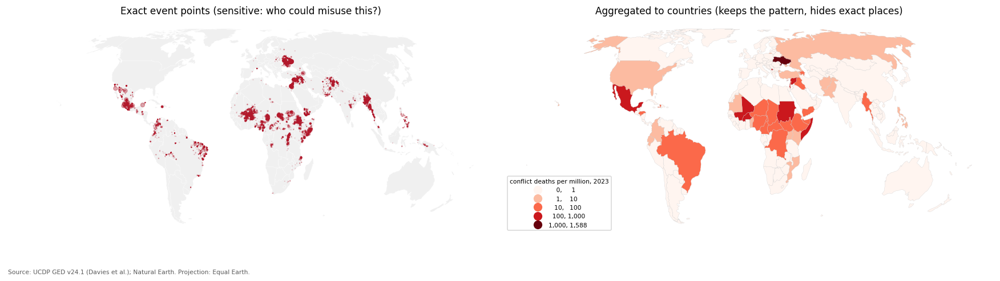

,NAME,deaths_2023,deaths_per_million,ndgain
112,Ukraine,70494.0,1588.2,52.6
160,N. Cyprus,290.0,889.6,NaN
12,Somalia,3906.0,383.2,27.3
65,Burkina Faso,6176.0,303.9,37.6
14,Sudan,7719.0,180.3,28.2
174,Kosovo,290.0,161.6,NaN
76,Israel,1323.0,146.1,60.0
108,Syria,2118.0,124.1,37.8


In [66]:
ged = pd.read_csv(TAB / "ucdp_ged_events_2023.csv")
ged_pts = gpd.GeoDataFrame(ged, geometry=gpd.points_from_xy(ged.longitude, ged.latitude), crs=4326)
print(f"{len(ged_pts):,} events, {ged_pts.deaths_best.sum():,.0f} deaths (best estimate); by type:", ged.type_of_violence.value_counts().to_dict())

per_c = gpd.sjoin(ged_pts, world[["ISO_A3_EH", "geometry"]], predicate="within", how="left").groupby("ISO_A3_EH").deaths_best.sum()
wc = world.set_index("ISO_A3_EH").join(per_c.rename("deaths_2023")).reset_index()
wc["deaths_per_million"] = wc.deaths_2023.fillna(0) / wc.POP_EST * 1e6
wc = wc[wc.CONTINENT != "Antarctica"].to_crs(8857)

fig, axes = plt.subplots(1, 2, figsize=(16, 4.8))
wc.plot(ax=axes[0], color="#f0f0f0", edgecolor="white", lw=0.2)
ged_pts.to_crs(8857).plot(ax=axes[0], markersize=np.clip(ged_pts.deaths_best, 1, 300) / 15, color="#b2182b", alpha=0.35)
axes[0].set_title("Exact event points (sensitive: who could misuse this?)")
wc.plot(ax=axes[1], column="deaths_per_million", scheme="UserDefined", classification_kwds={"bins": [1, 10, 100, 1000, wc.deaths_per_million.max()]},
        cmap="Reds", edgecolor="0.8", lw=0.2, legend=True,
        legend_kwds={"fmt": "{:,.0f}", "loc": "lower left", "fontsize": 7, "title": "conflict deaths per million, 2023", "title_fontsize": 7})
axes[1].set_title("Aggregated to countries (keeps the pattern, hides exact places)")
for a in axes: a.set_axis_off()
fig.text(0.01, 0.01, "Source: UCDP GED v24.1 (Davies et al.); Natural Earth. Projection: Equal Earth.", fontsize=7, color="0.35")
plt.tight_layout(); plt.show()
display(wc.nlargest(8, "deaths_per_million")[["NAME", "deaths_2023", "deaths_per_million", "ndgain"]].round(1))

### 8.6 Workflow memo & milestone (slide 48: 40–60′)
The milestone asks for: a finished thematic map (§8.1 or §8.2), **one design choice**, **one ethical consideration**, and **one AI suggestion**. The cell below writes a pre-filled memo skeleton (facts from this run) to `outputs/workflow_memo.md`. The reasoning sections are left for you to write.

In [67]:
memo = f'''# Workflow memo: {BRIEF["message"]}

## Data
- us_counties_acs2022 ({len(counties)} counties, EPSG:4269), ACS 2018–2022 5-year; joined from CSV on GEOID = geoid ({len(joined)} rows, 0 unmatched)
- world_countries_ne110m + World Bank GDP per capita 2022 + ND-GAIN 2022, joined on ISO_A3_EH ({world.gdp_pc_usd.notna().sum()} of {len(world)} countries with GDP)
- usgs_earthquakes_2025_m25_latlon.csv ({len(eq_pts)} points geocoded from lat/lon, EPSG:4326 → 4269)
- Data fix: 1 county with median_hh_income = -666,666,666 set to No data

## Steps
1. Join CSV attributes (GEOID read as text; integer keys would drop {(~matched).sum()} counties)
2. Classified poverty_pct: equal interval / quantile / natural breaks (breaks in §5.6); world GDP per capita: quantile vs natural breaks (§8.1)
3. Projected to EPSG:5070 (equal-area) with AK/HI insets
4. Final map: natural breaks {np.round(final_bins, 1).tolist()}
5. Spatial join: earthquakes → counties (count/mean/max mag), per 10,000 km²; zonal statistics: WorldPop and NLCD → Illinois counties
6. Global Moran's I for poverty_pct = {moran_I:.3f} (pseudo p = {p_sim:.3f})

## Design choice and why
- (write: e.g. natural breaks vs quantile; what changed on the map — {(yb["Quantile"] != yb["Natural breaks (Jenks)"]).sum()} counties change class)

## Ethical consideration
- (write: e.g. 20% vs 25% "high-poverty" threshold moves {len(moved)} counties; stigma of labelling places)

## AI suggestion captured
- (paste one suggestion from your AI map brief and whether you accepted it)

{SOURCE}
'''
(OUT / "workflow_memo.md").write_text(memo)
print(memo)

# Workflow memo: High poverty is regionally clustered (Delta, Appalachia, border, reservations), not random

## Data
- us_counties_acs2022 (3144 counties, EPSG:4269), ACS 2018–2022 5-year; joined from CSV on GEOID = geoid (3144 rows, 0 unmatched)
- world_countries_ne110m + World Bank GDP per capita 2022 + ND-GAIN 2022, joined on ISO_A3_EH (164 of 177 countries with GDP)
- usgs_earthquakes_2025_m25_latlon.csv (3754 points geocoded from lat/lon, EPSG:4326 → 4269)
- Data fix: 1 county with median_hh_income = -666,666,666 set to No data

## Steps
1. Join CSV attributes (GEOID read as text; integer keys would drop 318 counties)
2. Classified poverty_pct: equal interval / quantile / natural breaks (breaks in §5.6); world GDP per capita: quantile vs natural breaks (§8.1)
3. Projected to EPSG:5070 (equal-area) with AK/HI insets
4. Final map: natural breaks [10.0, 14.4, 19.3, 26.4, 55.8]
5. Spatial join: earthquakes → counties (count/mean/max mag), per 10,000 km²; zonal statistics: WorldPop and

In [68]:
print("Files written to", OUT.resolve())
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(OUT)):45s} {p.stat().st_size/1024:8.1f} kB")

Files written to /u/wz53/Global_study_experiments/outputs
  classification_three_schemes_slide.png           496.8 kB
  final_map_poverty_pct.pdf                       2352.0 kB
  final_map_poverty_pct.png                       1133.7 kB
  il_counties.geojson                              229.7 kB
  il_counties.gpkg                                 224.0 kB
  il_counties.kml                                  250.2 kB
  lab_outputs.gpkg                                5436.0 kB
  lisa_poverty_pct.csv                             170.2 kB
  make_classification_slide_figure.py                3.1 kB
  map_elements_median_income.pdf                  2352.3 kB
  map_elements_median_income.png                  1203.0 kB
  metadata_record.json                               1.7 kB
  shapefile/il_counties.cpg                          0.0 kB
  shapefile/il_counties.dbf                        116.7 kB
  shapefile/il_counties.prj                          0.2 kB
  shapefile/il_counties.shp               

---
## Appendix (slides 46–64: kept for reference, not covered in the lecture)

### A.1 GIS and remote sensing (slide 50)
GIS starts from objects; remote sensing starts from a signal. One step from signal to object: compute NDVI from the Sentinel-2 bands and threshold it into a "vegetation" class — the kind of product remote sensing hands to GIS.

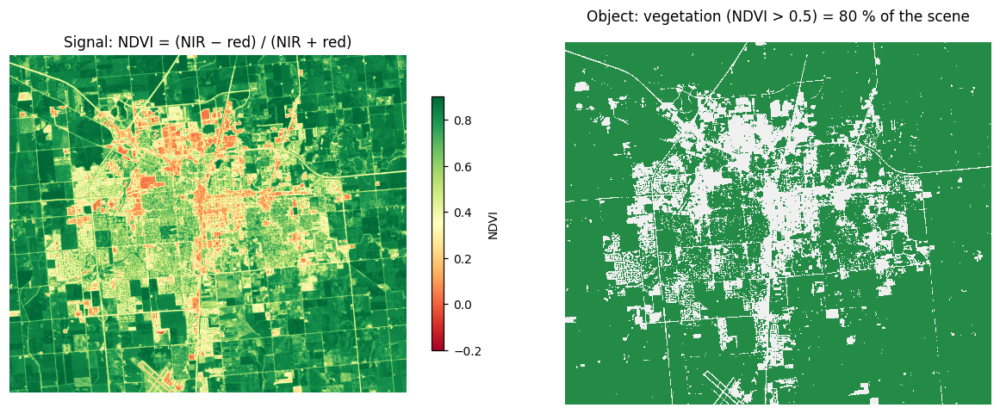

In [69]:
red, nir = s2[0].astype(float), s2[3].astype(float)
ndvi = (nir - red) / (nir + red)
veg = ndvi > 0.5
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
im = axes[0].imshow(ndvi, extent=s2_ext, cmap="RdYlGn", vmin=-0.2, vmax=0.9); fig.colorbar(im, ax=axes[0], shrink=0.7, label="NDVI")
axes[0].set_title("Signal: NDVI = (NIR − red) / (NIR + red)")
axes[1].imshow(veg, extent=s2_ext, cmap=mpl.colors.ListedColormap(["#f0f0f0", "#238b45"])); axes[1].set_title(f"Object: vegetation (NDVI > 0.5) = {100 * veg.mean():.0f} % of the scene")
for a in axes: a.set_axis_off()
plt.tight_layout(); plt.show()

### A.2 Pattern → hypothesis → test (cut slide 51, "Poverty in remote areas")
Slide 51's chain: **pattern** (poverty clusters where access is poor) → **hypothesis** (low accessibility → fewer opportunities) → **test**.
The data pack has no travel-time layer, so population density stands in as a rough proxy for accessibility. Treat the result as a first look, not a test: a correlation is not causal, and density is not accessibility.
§8.4 tests the "clusters" part formally with Moran's I.

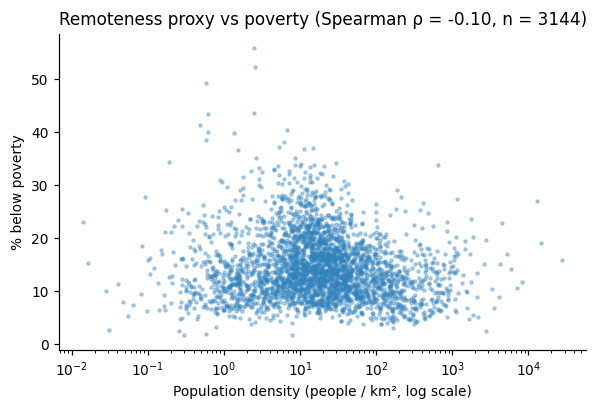

In [70]:
d = counties[["poverty_pct", "pop_density_km2"]].dropna()
rho = d.corr(method="spearman").iloc[0, 1]
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.scatter(d.pop_density_km2, d.poverty_pct, s=4, alpha=0.35, color="#3182bd")
ax.set_xscale("log"); ax.set_xlabel("Population density (people / km², log scale)"); ax.set_ylabel("% below poverty")
ax.set_title(f"Remoteness proxy vs poverty (Spearman ρ = {rho:.2f}, n = {len(d)})")
ax.spines[["top", "right"]].set_visible(False); plt.tight_layout(); plt.show()

### A.3 Ebola (cut slide 52) and geodatabases (cut slide 53)
- Ebola: *"the technology changed, the logic did not"* — the point-pattern reading of §2.3 is the same move.
- Geodatabases are Esri containers. QGIS can read File Geodatabases (OpenFileGDB driver), but for sharing with QGIS users the pack uses Shapefiles, GeoPackage, CSV and GeoTIFF:

In [71]:
drv = pyogrio.list_drivers()
print("OpenFileGDB available:", "OpenFileGDB" in drv, "| mode:", drv.get("OpenFileGDB"), "| GPKG:", drv.get("GPKG"), "| ESRI Shapefile:", drv.get("ESRI Shapefile"))

OpenFileGDB available: True | mode: rw | GPKG: rw | ESRI Shapefile: rw


### A.4 Understanding data "layers" (slides 54–55)
A map is a stack of layers, like the Google Maps example: background, then land use, then streets, then points of interest. The panels below build a map one layer at a time, with drawing order set by `zorder`.

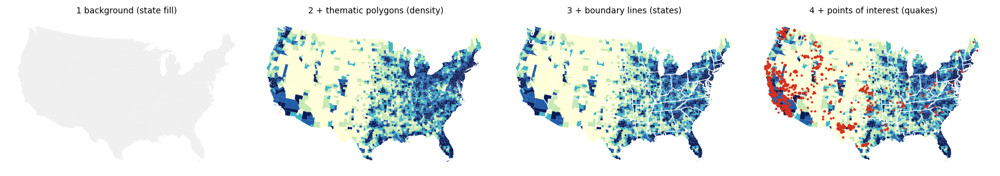

In [72]:
layers = [
    ("1 background (state fill)", lambda ax: states48.plot(ax=ax, color="#f0f0f0", zorder=1)),
    ("2 + thematic polygons (density)", lambda ax: lower48.plot(ax=ax, column="pop_density_km2", scheme="Quantiles", k=5,
                                                                cmap="YlGnBu", lw=0, zorder=2)),
    ("3 + boundary lines (states)", lambda ax: state_lines.plot(ax=ax, color="white", lw=0.6, zorder=3)),
    ("4 + points of interest (quakes)", lambda ax: q48.plot(ax=ax, markersize=2, color="#d7301f", zorder=4)),
]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for i, ax in enumerate(axes):
    for _, draw in layers[: i + 1]:
        draw(ax)
    ax.set_title(layers[i][0], fontsize=9); ax.set_axis_off()
plt.tight_layout(); plt.show()

### A.5 Geographic coordinates drawn as x/y = Plate Carrée (slides 56–57)
Plotting longitude and latitude directly as x and y produces the equidistant cylindrical (Plate Carrée) map. GeoPandas usually hides this by stretching the aspect ratio; forcing a 1:1 aspect shows the raw geometry.

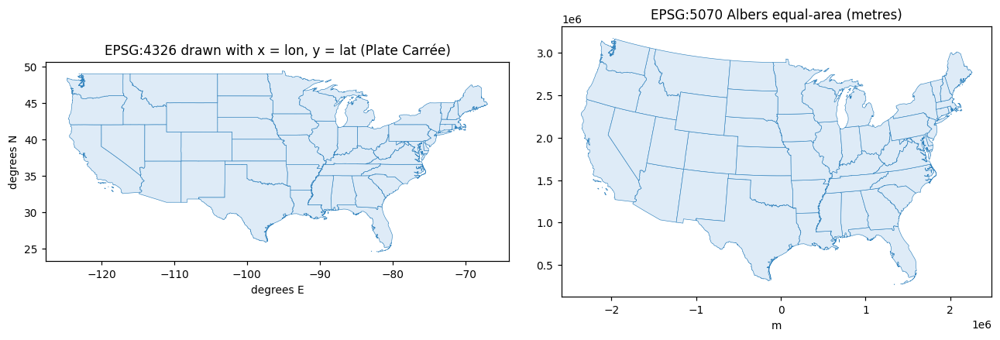

In [73]:
s48_geo = states48.to_crs(4326)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
s48_geo.plot(ax=a1, color="#deebf7", edgecolor="#3182bd", lw=0.4); a1.set_aspect(1)
a1.set_title("EPSG:4326 drawn with x = lon, y = lat (Plate Carrée)"); a1.set_xlabel("degrees E"); a1.set_ylabel("degrees N")
states48.plot(ax=a2, color="#deebf7", edgecolor="#3182bd", lw=0.4)
a2.set_title("EPSG:5070 Albers equal-area (metres)"); a2.set_xlabel("m"); a2.ticklabel_format(style="sci", scilimits=(0, 0))
plt.tight_layout(); plt.show()

### A.6 Projection matrices and the UN emblem (slides 58–60)
The speaker note to slide 58: the UN chose an **azimuthal equidistant** projection centred on the North Pole — "one world" in a circle, no nation at the centre. Distances from the pole are true; shapes far from it are not.

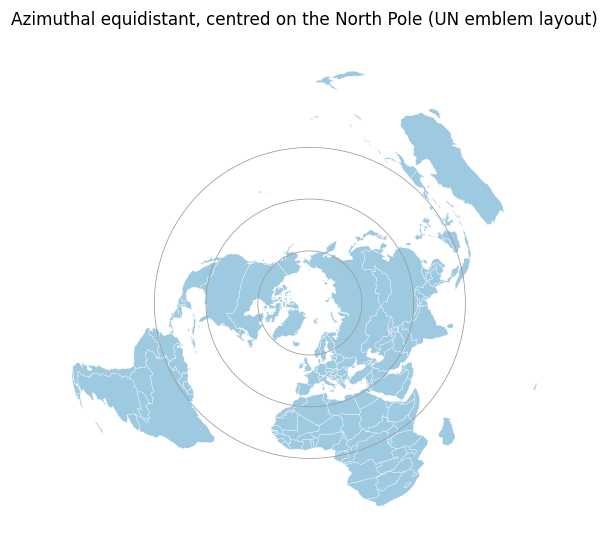

In [74]:
aeqd = world[world.CONTINENT != "Antarctica"].clip((-180, -60, 180, 90)).to_crs("+proj=aeqd +lat_0=90 +lon_0=0 +datum=WGS84 +units=m")
fig, ax = plt.subplots(figsize=(6, 6))
aeqd.plot(ax=ax, color="#9ecae1", edgecolor="white", lw=0.2)
for la in (0, 30, 60):
    ring = gpd.GeoSeries([LineString([(lo, la) for lo in np.linspace(-180, 180, 361)])], crs=4326).to_crs(aeqd.crs)
    ring.plot(ax=ax, color="0.6", lw=0.5)
ax.set_title("Azimuthal equidistant, centred on the North Pole (UN emblem layout)"); ax.set_axis_off(); plt.show()

### A.7 Eight places a map loses information (slide 61): checks on this data
| Stage | What this data pack loses | Check below |
|---|---|---|
| 2 Collection | ACS is a sample, and margins of error were dropped from the pack | small-population counties = least reliable estimates |
| 3 Encoding | "not available" stored as −666,666,666 | fixed in §3.9 |
| 4 Aggregation | county units hide within-county variation | §6.4 |
| 5 Scale | 1:5,000,000 generalised boundaries | area error vs county size (next cell) |
| 7 Classification | no default symbol for "we do not know" | hatched "No data" in §5.5 |

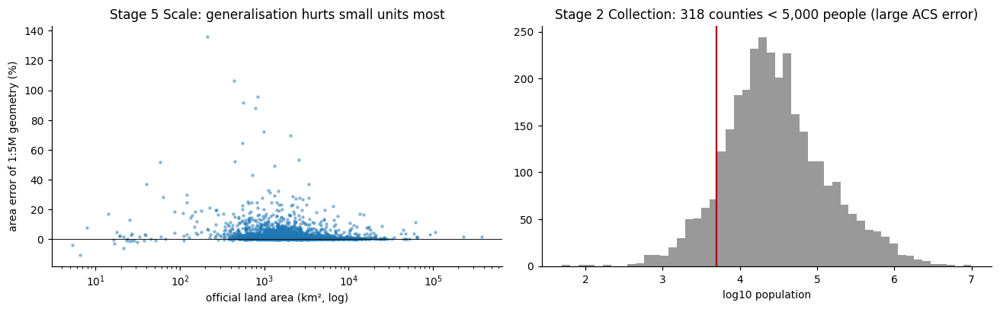

Median |area error|: 1.2 % ; worst: ['Grand Isle County', 'VT'] 136%


In [75]:
# Cartographic boundaries are clipped to the shoreline, so compare with LAND area (not land + water).
cmp["pct_area_error"] = 100 * (cmp.area_km2_albers / cmp.land_km2 - 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].scatter(cmp.land_km2, cmp.pct_area_error, s=4, alpha=0.4)
axes[0].set_xscale("log"); axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_xlabel("official land area (km², log)"); axes[0].set_ylabel("area error of 1:5M geometry (%)")
axes[0].set_title("Stage 5 Scale: generalisation hurts small units most")
axes[1].hist(np.log10(counties.population), bins=50, color="0.6")
axes[1].axvline(np.log10(5_000), color="#b30000"); axes[1].set_xlabel("log10 population")
axes[1].set_title(f"Stage 2 Collection: {(counties.population < 5000).sum()} counties < 5,000 people (large ACS error)")
for a in axes: a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()
print("Median |area error|:", round(cmp.pct_area_error.abs().median(), 1), "% ; worst:",
      cmp.loc[cmp.pct_area_error.abs().idxmax(), ["county_label", "state_abbr"]].tolist(), f"{cmp.pct_area_error.abs().max():.0f}%")

### A.8 Discussion slides (62–63) and the prompt template (slide 64)
Slides 62–63 are discussion prompts (Burgos-Thorsen 2025; Kwan 2002). Slide 64 is the AI prompt template used in §8.2.